In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


retrofit_colours = ['#3e7ad3', '#518dca', '#5ba0c0', '#5fb4b5', '#f1a800']
baseline_colours = ['#3e7ad3']
control_colours =  ['#005c83', '#49d3ff'] #['#1F70C1', '#b4e8ff']
fabric_colours = ['#674b00', '#906f00', '#bc9400', '#eabc17'] #['#3DDBD9', '#3DDBD9', '#3DDBD9', '#3DDBD9']
energy_colours = ['#7b0044', '#ff7eb6'] #['#82CFFF', '#82CFFF']
combo_colours =  ['#6746a6', '#a67ee6', '#ecc0ff'] #['#110158', '#6947a8', '#be95ff'] #['#BE95FF', '#BE95FF', '#BE95FF']

intermediate_colors = baseline_colours + control_colours + fabric_colours + energy_colours + combo_colours

full_custom_labels = ['Baseline',
                 'Control - Four zones',
                 'Control - All zones',
                 'Fabric - Low cost',
                 'Fabric - Shallow',
                 'Fabric - Deep',
                 'Fabric - Passivhaus',
                 'System\nASHP',
                 'System\nASHP + PV/Batt',
                 'Combo\nPassivhaus + All Control',
                 'Combo\nEnergy System + All Control',
                 'Combo\nBest Fabric & System + All Control']

custom_labels = ['+ Four zones controlled',
                 '+ All zones controlled',
                 'Baseline + Low cost',
                 '+ Shallow',
                 '+ Deep',
                 '+ Passivhaus',
                 'Baseline + ASHP',
                 '+ PV/Batt',
                 'Passivhaus + All Control',
                 'Energy System + All Control',
                 'Best Fabric & System + All Control']

def align_yaxis(ax1, ax2):
    """Align zeros of the two axes, zooming them out by same ratio"""
    axes = (ax1, ax2)
    extrema = [ax.get_ylim() for ax in axes]
    tops = [extr[1] / (extr[1] - extr[0]) for extr in extrema]
    # Ensure that plots (intervals) are ordered bottom to top:
    if tops[0] > tops[1]:
        axes, extrema, tops = [list(reversed(l)) for l in (axes, extrema, tops)]

    # How much would the plot overflow if we kept current zoom levels?
    tot_span = tops[1] + 1 - tops[0]

    b_new_t = extrema[0][0] + tot_span * (extrema[0][1] - extrema[0][0])
    t_new_b = extrema[1][1] - tot_span * (extrema[1][1] - extrema[1][0])
    axes[0].set_ylim(extrema[0][0], b_new_t)
    axes[1].set_ylim(t_new_b, extrema[1][1])


<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


In [14]:
# Define the base path and the pattern to match
base_path = '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/Eplus_files/'
pattern1 = 'Eplus-env-2024-05-17'

# Walk through the directory tree
matching_dirs = []
for root, dirs, files in os.walk(base_path):
    for dir_name in dirs:
        if dir_name.startswith(pattern1):
            full_path = os.path.join(root, dir_name)
            matching_dirs.append(full_path)


new_columns = ['cost', 'gas_cost', 'electricity_cost','cumulative_reward',
               'mean_reward', 'cumulative_emissions', 'mean_emissions',
               'cumulative_comfort_penalty', 'mean_comfort_penalty',
               'cumulative_emissions_penalty', 'mean_emissions_penalty',
               'cumulative_air_quality_penalty', 'mean_air_quality_penalty',
               'comfort_violation (%)', 'mean_comfort_violation',
               'std_comfort_violation', 'cumulative_comfort_violation',
               'mean_air_quality_violation', 'std_air_quality_violation',
               'cumulative_air_quality_violation', 'length(timesteps)',
               'time_elapsed(seconds)']


reps = np.arange(5)
cases = np.arange(15)
data = {}

for dir_name in matching_dirs:
    key = dir_name.split("/")[-1].split("Eplus-env-2024-05-")[-1][3:-35]
    file_name = "/progress.csv"
    path = dir_name + file_name
    # Check if the directory exists
    if os.path.exists(dir_name):
        df = pd.read_csv(path)
        df.columns = new_columns
        emissions = df["cumulative_emissions"].values[0]/1000
        cost = df["cost"].values[0]/100
        mean_comfort = df["mean_comfort_violation"].values[0]
        std_comfort = df["std_comfort_violation"].values[0]
        data[key] = [emissions,cost,mean_comfort, std_comfort]
    else:
        print(f"Directory '{dir_name}' does not exist. Skipping...")

out_data = pd.DataFrame(data)

# Define the desired column order
desired_order = [
    'no_control_case_0_rep',
    'four_zones_controlled_case_0_rep',
    'all_zones_controlled_case_0_rep',
    'no_control_case_1_rep',
    'no_control_case_2_rep',
    'no_control_case_3_rep',
    'no_control_case_4_rep',
    'no_control_case_5_rep',
    'no_control_case_10_rep0',
    'all_zones_controlled_case_4_rep',
    'all_zones_controlled_case_10_rep0',
    'all_zones_controlled_case_14_rep0'
]

# Reindex the DataFrame according to the desired column order
out_data = out_data[desired_order]

In [15]:
out_data

,no_control_case_0_rep,four_zones_controlled_case_0_rep,all_zones_controlled_case_0_rep,no_control_case_1_rep,no_control_case_2_rep,no_control_case_3_rep,no_control_case_4_rep,no_control_case_5_rep,no_control_case_10_rep0,all_zones_controlled_case_4_rep,all_zones_controlled_case_10_rep0,all_zones_controlled_case_14_rep0
0,4.107830,3.575438,3.093210,3.851788,2.995755,1.013312,0.833155,1.443799,1.279069,0.625931,1.017314,0.105736
1,1966.086106,1714.776512,1494.846905,1841.161726,1436.072211,690.835502,603.239013,2819.274134,2514.911575,499.462140,2034.676538,218.425056
2,0.004961,0.006233,0.014975,0.005343,0.007408,0.120285,0.107808,0.005101,0.005438,0.850133,0.013896,0.817444
3,0.014755,0.048476,0.125125,0.015196,0.018364,0.286024,0.297299,0.015042,0.015802,2.028391,0.110962,1.937869


In [16]:
# Define the base path and the pattern to match
base_path = '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/Eplus_files/'
pattern1 = 'Eplus-env-2024-05-17'

# Walk through the directory tree
matching_dirs = []
for root, dirs, files in os.walk(base_path):
    for dir_name in dirs:
        if dir_name.startswith(pattern1):
            full_path = os.path.join(root, dir_name)
            matching_dirs.append(full_path)


new_columns = ['cost', 'gas_cost', 'electricity_cost','cumulative_reward',
               'mean_reward', 'cumulative_emissions', 'mean_emissions',
               'cumulative_comfort_penalty', 'mean_comfort_penalty',
               'cumulative_emissions_penalty', 'mean_emissions_penalty',
               'cumulative_air_quality_penalty', 'mean_air_quality_penalty',
               'comfort_violation (%)', 'mean_comfort_violation',
               'std_comfort_violation', 'cumulative_comfort_violation',
               'mean_air_quality_violation', 'std_air_quality_violation',
               'cumulative_air_quality_violation', 'length(timesteps)',
               'time_elapsed(seconds)']


reps = np.arange(5)
cases = np.arange(15)
data = {}

for dir_name in matching_dirs:
    key = dir_name.split("/")[-1].split("Eplus-env-2024-05-")[-1][3:-35]
    file_name = "/progress.csv"
    path = dir_name + file_name
    # Check if the directory exists
    if os.path.exists(dir_name):
        df = pd.read_csv(path)
        df.columns = new_columns
        emissions = df["cumulative_emissions"].values[0]/1000
        cost = df["cost"].values[0]/100
        mean_comfort = df["mean_comfort_violation"].values[0]
        std_comfort = df["std_comfort_violation"].values[0]
        data[key] = [emissions,cost,mean_comfort, std_comfort]
    else:
        print(f"Directory '{dir_name}' does not exist. Skipping...")

out_data = pd.DataFrame(data)

# Define the desired column order
desired_order = [
    'no_control_case_0_rep',
    'four_zones_controlled_case_0_rep',
    'all_zones_controlled_case_0_rep',
    'no_control_case_1_rep',
    'no_control_case_2_rep',
    'no_control_case_3_rep',
    'no_control_case_4_rep',
    'no_control_case_5_rep',
    'no_control_case_10_rep0',
    'all_zones_controlled_case_4_rep',
    'all_zones_controlled_case_10_rep0',
    'all_zones_controlled_case_14_rep0'
]

# Reindex the DataFrame according to the desired column order
out_data = out_data[desired_order]

# Set the new index
out_data.index = ['emissions', 'bill', "mean_comfort", "std_comfort"]
out_data.loc["cost"] = [0, 240, 480, 3800, 16000, 51000, 71000, 28000, 48000, 71480, 48500, 120000]
out_data = out_data.T

temp = out_data
# Relabel experiment names


# Calculate the relative difference in mean for each column compared to 'no_control'
relative_bill = out_data['bill'] - out_data['bill'].loc['no_control_case_0_rep']
out_data["savings"] = -relative_bill
out_data['payback'] = out_data.apply(lambda row: row['cost'] / row['savings'] if row['savings'] != 0 else np.nan, axis=1)
out_data['payback'] = out_data['payback'].apply(lambda x: max(x, 0) if pd.notnull(x) else 0)

out_data["savings10"] = out_data["savings"] * 10
out_data["relative_savings"] =  - (out_data["savings"]/out_data.loc["no_control_case_0_rep","bill"]) * 100
out_data["relative_emissions"] = (out_data["emissions"]/ out_data.loc["no_control_case_0_rep","emissions"] * 100) - 100
out_data["absolute_emissions"] = (out_data.loc["no_control_case_0_rep","emissions"] - out_data["emissions"])
out_data["bang_for_buck"] = (out_data["savings"]/out_data["cost"])
out_data["emissions_for_buck"] = (out_data.loc["no_control_case_0_rep","emissions"] - out_data["emissions"])/ (out_data["cost"] /1000)
out_data.index = full_custom_labels
df_baseline = out_data
df = out_data.drop(['Baseline'], axis=0 )

In [18]:
out_data

,emissions,bill,mean_comfort,std_comfort,cost,savings,payback,savings10,relative_savings,relative_emissions,absolute_emissions,bang_for_buck,emissions_for_buck
Baseline,4.107830,1966.086106,0.004961,0.014755,0.0,-0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,NaN,NaN
Control - Four zones,3.575438,1714.776512,0.006233,0.048476,240.0,251.309594,0.954997,2513.095935,-12.782227,-12.960422,0.532392,1.047123,2.218300
Control - All zones,3.093210,1494.846905,0.014975,0.125125,480.0,471.239201,1.018591,4712.392005,-23.968391,-24.699657,1.014620,0.981748,2.113791
Fabric - Low cost,3.851788,1841.161726,0.005343,0.015196,3800.0,124.924380,30.418402,1249.243797,-6.353963,-6.233009,0.256041,0.032875,0.067379
Fabric - Shallow,2.995755,1436.072211,0.007408,0.018364,16000.0,530.013895,30.187888,5300.138951,-26.957817,-27.072070,1.112075,0.033126,0.069505
Fabric - Deep,1.013312,690.835502,0.120285,0.286024,51000.0,1275.250604,39.992139,12752.506041,-64.862398,-75.332172,3.094517,0.025005,0.060677
Fabric - Passivhaus,0.833155,603.239013,0.107808,0.297299,71000.0,1362.847093,52.096820,13628.470929,-69.317772,-79.717888,3.274675,0.019195,0.046122
System\nASHP,1.443799,2819.274134,0.005101,0.015042,28000.0,-853.188028,0.000000,-8531.880283,43.395252,-64.852505,2.664030,-0.030471,0.095144
System\nASHP + PV/Batt,1.279069,2514.911575,0.005438,0.015802,48000.0,-548.825469,0.000000,-5488.254694,27.914620,-68.862655,2.828761,-0.011434,0.058933
Combo\nPassivhaus + All Control,0.625931,499.462140,0.850133,2.028391,71480.0,1466.623966,48.737783,14666.239659,-74.596121,-84.762478,3.481898,0.020518,0.048712


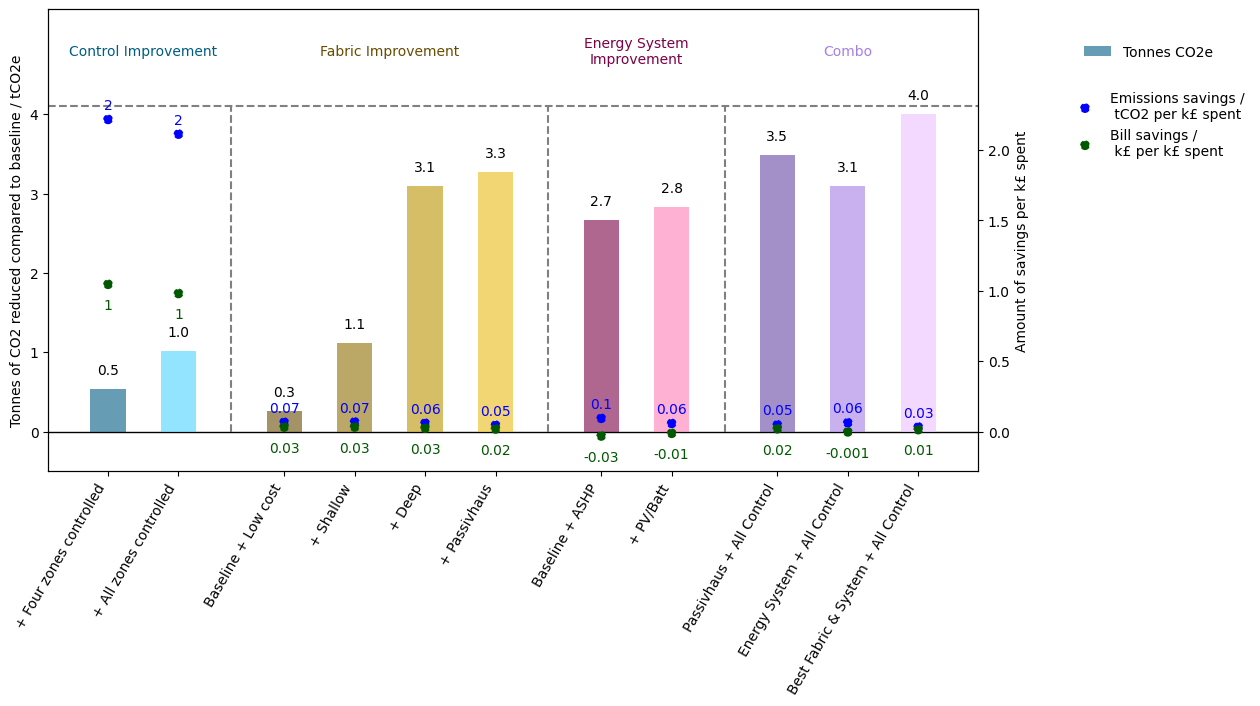

In [9]:
# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

baselines = out_data["absolute_emissions"].iloc[:1]
control = out_data["absolute_emissions"].iloc[1:3]
fabric = out_data["absolute_emissions"].iloc[3:7]
system = out_data["absolute_emissions"].iloc[7:9]
best = out_data["absolute_emissions"].iloc[9:]

savings_baselines = out_data["emissions_for_buck"].iloc[:1]
savings_control = out_data["emissions_for_buck"].iloc[1:3]
savings_fabric = out_data["emissions_for_buck"].iloc[3:7]
savings_system = out_data["emissions_for_buck"].iloc[7:9]
savings_best = out_data["emissions_for_buck"].iloc[9:]

bills_baselines = out_data["bang_for_buck"].iloc[:1]
bills_control = out_data["bang_for_buck"].iloc[1:3]
bills_fabric = out_data["bang_for_buck"].iloc[3:7]
bills_system = out_data["bang_for_buck"].iloc[7:9]
bills_best = out_data["bang_for_buck"].iloc[9:]

# Plot bars
#base = ax1.bar(np.arange(1), savings_baselines, color=intermediate_colors[0], width=0.5, alpha=0.6, label='Baseline')
cont = ax1.bar(np.arange(0,2)+0.5, control, color=intermediate_colors[1:3], width=0.5, alpha=0.6, label='Tonnes CO2e')
fab = ax1.bar(np.arange(2,6)+1, fabric, color=intermediate_colors[3:7], width=0.5, alpha=0.6)
sys = ax1.bar(np.arange(6,8)+1.5, system, color=intermediate_colors[7:9], width=0.5, alpha=0.6)
bes = ax1.bar(np.arange(8,11)+2, best, color=intermediate_colors[9:], width=0.5, alpha=0.6)

plt.yticks(ticks=np.arange(0, 5, 1), labels=[x for x in np.arange(0, 5,1)])

plt.axhline(y=4.1, xmin=0, xmax=1, color='gray', linestyle='--')

# Add data labels
for bar in cont:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 0.15, f'{height:.1f}', color='black', ha='center', va='bottom')

for bar in fab:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 0.15, f'{height:.1f}', color='black', ha='center', va='bottom')

for bar in sys:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 0.15, f'{height:.1f}', color='black', ha='center', va='bottom')

for bar in bes:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 0.15, f'{height:.1f}', color='black', ha='center', va='bottom')

# Secondary y-axis
ax2 = ax1.twinx()
#ax2.scatter(np.arange(1), baselines, color='#F0F0F0', marker='o', linestyle='--', label='Emissions')
ax2.scatter(np.arange(0,2)+0.5, savings_control, color='blue', marker='o', linestyle='--')
ax2.scatter(np.arange(2,6)+1, savings_fabric, color='blue', marker='o', linestyle='--')
ax2.scatter(np.arange(6,8)+1.5, savings_system, color='blue', marker='o', linestyle='--')
ax2.scatter(np.arange(8,11)+2, savings_best, color='blue', marker='o', linestyle='--', label='Emissions savings /\n tCO2 per k£ spent')
ax2.scatter(np.arange(0,2)+0.5, bills_control, color='#005800', marker='o', linestyle='--')
ax2.scatter(np.arange(2,6)+1, bills_fabric, color='#005800', marker='o', linestyle='--')
ax2.scatter(np.arange(6,8)+1.5, bills_system, color='#005800', marker='o', linestyle='--')
ax2.scatter(np.arange(8,11)+2, bills_best, color='#005800', marker='o', linestyle='--', label='Bill savings /\n k£ per k£ spent')

plt.yticks(ticks=np.arange(0, 2.5, 0.5), labels=[x for x in np.arange(0, 2.5, 0.5)])

# Add data labels for the scatter plot
def add_scatter_labels_emissions(ax, x_data, y_data):
    for (x, y) in zip(x_data, y_data):
        ax.text(x, y + 0.05, f'{y:.1g}', color="blue", ha='center', va='bottom')

def add_scatter_labels_buck(ax, x_data, y_data):
    for (x, y) in zip(x_data, y_data):
        ax.text(x, y - 0.2, f'{y:.1g}', color="#005800", ha='center', va='bottom')

#add_scatter_labels_emissions(ax2, np.arange(1), baselines)
add_scatter_labels_emissions(ax2, np.arange(0,2) + 0.5, savings_control)
add_scatter_labels_emissions(ax2, np.arange(2, 6) + 1, savings_fabric)
add_scatter_labels_emissions(ax2, np.arange(6, 8) + 1.5, savings_system)
add_scatter_labels_emissions(ax2, np.arange(8, 11) + 2, savings_best)
#add_scatter_labels_buck(ax2, np.arange(1), bills_baselines)
add_scatter_labels_buck(ax2, np.arange(0,2) + 0.5, bills_control)
add_scatter_labels_buck(ax2, np.arange(2, 6) + 1, bills_fabric)
add_scatter_labels_buck(ax2, np.arange(6, 8) + 1.5, bills_system)
add_scatter_labels_buck(ax2, np.arange(8, 11) + 2, bills_best)

# Add labels
ax2.text(1, 2.7, 'Control Improvement', ha='center', va='center', color=intermediate_colors[1])
ax2.text(4.5, 2.7, 'Fabric Improvement', ha='center', va='center', color=intermediate_colors[3])
ax2.text(8, 2.7, 'Energy System\nImprovement', ha='center', va='center', color=intermediate_colors[7])
ax2.text(11, 2.7, 'Combo', ha='center', va='center', color=intermediate_colors[10])
plt.xticks(np.concatenate([np.arange(0,2)+0.5, np.arange(2,6)+1, np.arange(6,8)+1.5, np.arange(8,11)+2]), custom_labels, rotation=60, ha='right')


# Add labels
ax1.set_xticks(np.concatenate([np.arange(0,2)+0.5, np.arange(2,6)+1, np.arange(6,8)+1.5, np.arange(8,11)+2]))
ax1.set_xticklabels(custom_labels, rotation=60, ha='right')
ax1.set_ylim([-0.5,5])
ax2.set_ylim([-0.1,3.0])

ax1.axhline(xmin=0, xmax=14, y=0, color="black", linestyle='-', linewidth=1, zorder=0)

# Add titles
ax1.set_ylabel('Tonnes of CO2 reduced compared to baseline / tCO2e')
ax2.set_ylabel('Amount of savings per k£ spent')
#plt.title('Effect of Different Retrofit Options on Annual Energy Bill and Emissions')

# Add a vertical lines

#ax1.vlines(x=0.75, ymin=0, ymax=4.1, color='gray', linestyle='--')
ax1.vlines(x=2.25, ymin=0, ymax=4.1, color='gray', linestyle='--')
ax1.vlines(x=6.75, ymin=0, ymax=4.1, color='gray', linestyle='--')
ax1.vlines(x=9.25, ymin=0, ymax=4.1, color='gray', linestyle='--')



align_yaxis(ax1, ax2)
ax1.legend(loc='upper left', bbox_to_anchor=(1.1, 0.95), frameon=False)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 0.85), frameon=False)
# Tightening and show
#fig.tight_layout()
#plt.savefig("reduction_potential.svg")
plt.show()

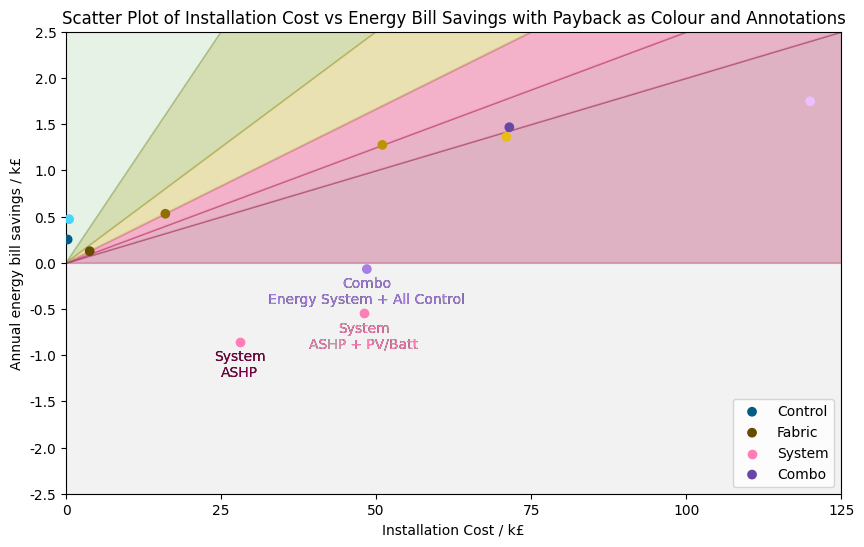

In [525]:
plt.figure(figsize=(10, 6))

control = df[df.index.str.contains("Control - ")]
fabric = df[df.index.str.contains("Fabric - ")]
system = df[df.index.str.contains("System\n")]
combo = df[df.index.str.contains("Combo")]

scatter = plt.scatter(control['cost'], control['savings'], color=intermediate_colors[1:3],zorder=3, label="Control")
scatter = plt.scatter(fabric['cost'], fabric['savings'], color=intermediate_colors[3:7],zorder=3, label="Fabric")
scatter = plt.scatter(system['cost'], system['savings'], color=intermediate_colors[8:9],zorder=3, label="System")
scatter = plt.scatter(combo['cost'], combo['savings'], color=intermediate_colors[9:],zorder=3, label="Combo")

# Annotating each point with the payback year
for i, row in df.iterrows():
    if row['savings'] <  0:
        plt.annotate(f"{i}", (row['cost'], row['savings']), textcoords="offset points", xytext=(0, -25), ha='center')



# Plotting and filling the areas between the lines y = x and y = (1/n)x
x_line = np.linspace(0,125000,400)
y_ax = np.linspace(0,0,400)

y_lines = [(1/n) * x_line for n in [10, 20, 30,40,50]]
colors = ['#749000', '#bb9d00', '#da0052', '#b60046', '#93003a']


# Shade above the line y = x in green
plt.fill_between(x_line, y_lines[0], 125000, color='#008000', alpha=0.1, zorder=1)
plt.fill_between(x_line, 0, -2500, color='gray', alpha=0.1, zorder=1)

# Fill the areas between the lines
for i in range(len(y_lines)-1):
    plt.fill_between(x_line, y_lines[i], y_lines[i+1], color=colors[i], alpha=0.3)

# Fill the area between the last line and the x-axis
plt.fill_between(x_line, y_lines[-1], 0, color=colors[-1], alpha=0.3)

# Plotting the lines y = x, y = (1/10)x, etc., with corresponding colors
for i in range(len(y_lines)):
    plt.plot(x_line, y_lines[i], linestyle='-', color='gray', alpha=0.1)

# Annotating each point with the payback year
count=1
for i, row in df.iterrows():
    if row['savings'] < 0:
        plt.annotate(f"{i}", (row['cost'], row['savings']), textcoords="offset points", xytext=(0, -25), ha='center', color=intermediate_colors[count])
    count = count + 1

# Modify x-axis labels to show in k£
plt.xticks(ticks=np.arange(0, 130000, 25000), labels=[f'{int(x/1000)}' for x in np.arange(0, 130000, 25000)])
plt.yticks(ticks=np.arange(-3000, 3000, 500), labels=[f'{(x/1000)}' for x in np.arange(-3000, 3000, 500)])

# Set the y-axis to start and finish with the x-axis
plt.ylim(-2500, 2500)
plt.xlim(0, 125000)

plt.legend(loc='lower right')

plt.xlabel('Installation Cost / k£')
plt.ylabel('Annual energy bill savings / k£')
plt.title('Scatter Plot of Installation Cost vs Energy Bill Savings with Payback as Colour and Annotations')

plt.show()

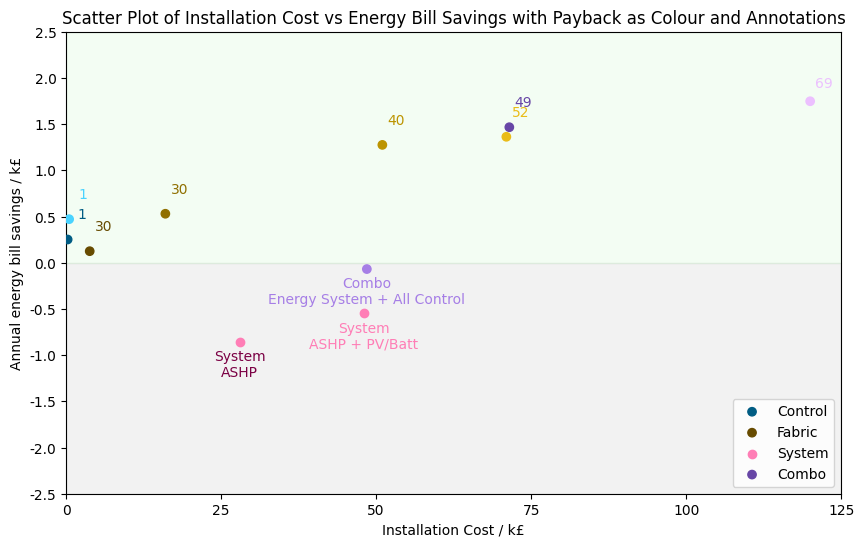

In [530]:
plt.figure(figsize=(10, 6))

# Scatter plot for non-negative payback with colormap
control = df[df.index.str.contains("Control - ")]
fabric = df[df.index.str.contains("Fabric - ")]
system = df[df.index.str.contains("System\n")]
combo = df[df.index.str.contains("Combo")]

scatter = plt.scatter(control['cost'], control['savings'], color=intermediate_colors[1:3],zorder=3, label="Control")
scatter = plt.scatter(fabric['cost'], fabric['savings'], color=intermediate_colors[3:7],zorder=3, label="Fabric")
scatter = plt.scatter(system['cost'], system['savings'], color=intermediate_colors[8:9],zorder=3, label="System")
scatter = plt.scatter(combo['cost'], combo['savings'], color=intermediate_colors[9:],zorder=3, label="Combo")

# Annotating each point with the payback year
count=1
for i, row in df.iterrows():
    if row['payback'] > 0:
        if row['payback'] > 60:
            plt.annotate(f"{row['payback']:.0f}", (row['cost'], row['savings']), textcoords="offset points", xytext=(10, 10), ha='center', color=intermediate_colors[count])
        else:
            plt.annotate(f"{row['payback']:.0f}", (row['cost'], row['savings']), textcoords="offset points", xytext=(10, 15), ha='center', color=intermediate_colors[count])
    else:
        plt.annotate(f"{i}", (row['cost'], row['savings']), textcoords="offset points", xytext=(0, -25), ha='center', color=intermediate_colors[count])
    count = count + 1

plt.fill_between(x_line, 0, -2500, color='gray', alpha=0.1, zorder=1)
plt.fill_between(x_line, 0, 2500, color='lightgreen', alpha=0.1, zorder=1)

# Modify x-axis labels to show in k£
plt.xticks(ticks=np.arange(0, 130000, 25000), labels=[f'{int(x/1000)}' for x in np.arange(0, 130000, 25000)])
plt.yticks(ticks=np.arange(-3000, 3000, 500), labels=[f'{(x/1000)}' for x in np.arange(-3000, 3000, 500)])

# Set the y-axis to start and finish with the x-axis
plt.ylim(-2500, 2500)
plt.xlim(0, 125000)


plt.xlabel('Installation Cost / k£')
plt.ylabel('Annual energy bill savings / k£')
plt.title('Scatter Plot of Installation Cost vs Energy Bill Savings with Payback as Colour and Annotations')
plt.legend(loc='lower right')
plt.show()


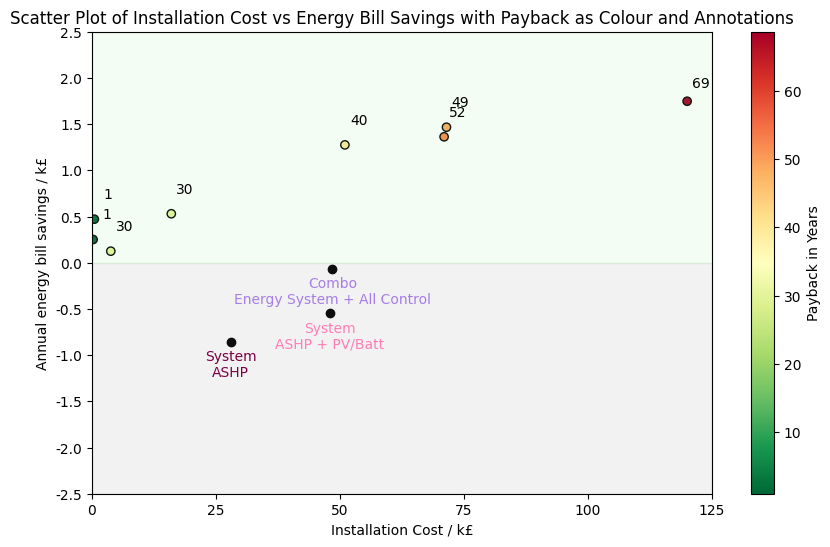

In [527]:
plt.figure(figsize=(10, 6))


# Split data into two sets: negative and non-negative payback
negative_payback = df[df['savings'] < 0]
non_negative_payback = df[df['savings'] > 0]

# Scatter plot for non-negative payback with colormap
scatter = plt.scatter(non_negative_payback['cost'], non_negative_payback['savings'],
                      c=non_negative_payback['payback'], cmap='RdYlGn_r', edgecolor='k')
plt.colorbar(scatter, label='Payback in Years')

# Scatter plot for negative payback in black
plt.scatter(negative_payback['cost'], negative_payback['savings'], color='black', edgecolor='k')

# Annotating each point with the payback year
count=1
for i, row in df.iterrows():
    if row['payback'] > 0:
        if row['payback'] > 60:
            plt.annotate(f"{row['payback']:.0f}", (row['cost'], row['savings']), textcoords="offset points", xytext=(10, 10), ha='center', color='black')
        else:
            plt.annotate(f"{row['payback']:.0f}", (row['cost'], row['savings']), textcoords="offset points", xytext=(10, 15), ha='center', color='black')
    else:
        plt.annotate(f"{i}", (row['cost'], row['savings']), textcoords="offset points", xytext=(0, -25), ha='center', color=intermediate_colors[count])
    count = count + 1


# Modify x-axis labels to show in k£
plt.xticks(ticks=np.arange(0, 130000, 25000), labels=[f'{int(x/1000)}' for x in np.arange(0, 130000, 25000)])
plt.yticks(ticks=np.arange(-3000, 3000, 500), labels=[f'{(x/1000)}' for x in np.arange(-3000, 3000, 500)])

# Set the y-axis to start and finish with the x-axis
plt.ylim(-2500, 2500)
plt.xlim(0, 125000)

plt.fill_between(x_line, 0, -2500, color='gray', alpha=0.1, zorder=1)
plt.fill_between(x_line, 0, 2500, color='lightgreen', alpha=0.1, zorder=1)

plt.xlabel('Installation Cost / k£')
plt.ylabel('Annual energy bill savings / k£')
plt.title('Scatter Plot of Installation Cost vs Energy Bill Savings with Payback as Colour and Annotations')
#plt.legend()
plt.show()


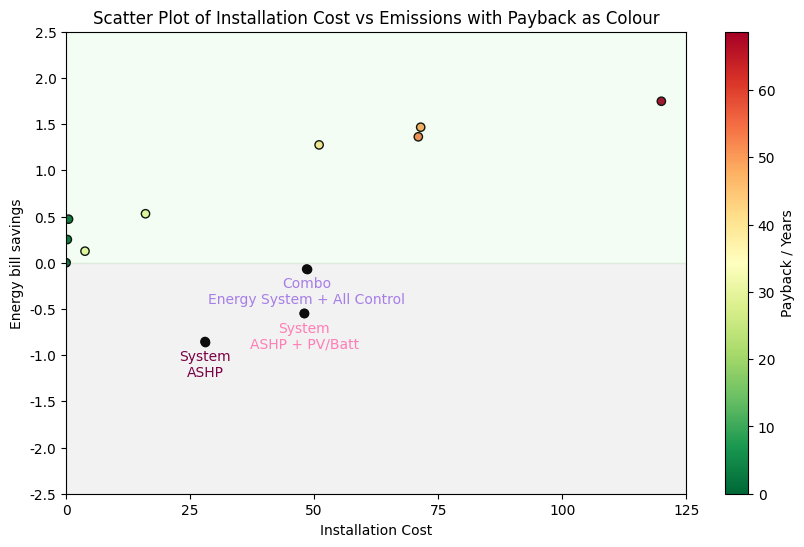

In [532]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(out_data['cost'], out_data['savings'], c=out_data['payback'], cmap='RdYlGn_r', edgecolor='k')
plt.colorbar(scatter, label='Payback / Years')
negative = out_data[out_data['savings'] < 0]
scatter = plt.scatter(negative['cost'], negative['savings'], color='black')

# Annotating each point with the payback year
count=1
for i, row in df.iterrows():
    if row['savings'] < 0:
        plt.annotate(f"{i}", (row['cost'], row['savings']), textcoords="offset points", xytext=(0, -25), ha='center', color=intermediate_colors[count])
    count = count + 1
plt.ylim([-2000, 2000])
plt.xlim([0,125000])

plt.fill_between(x_line, 0, -2500, color='gray', alpha=0.1, zorder=1)
plt.fill_between(x_line, 0, 2500, color='lightgreen', alpha=0.1, zorder=1)

# Modify x-axis labels to show in k£
plt.xticks(ticks=np.arange(0, 130000, 25000), labels=[f'{int(x/1000)}' for x in np.arange(0, 130000, 25000)])
plt.yticks(ticks=np.arange(-3000, 3000, 500), labels=[f'{(x/1000)}' for x in np.arange(-3000, 3000, 500)])

# Set the y-axis to start and finish with the x-axis
plt.ylim(-2500, 2500)
plt.xlim(0, 125000)

plt.xlabel('Installation Cost')
plt.ylabel('Energy bill savings')
plt.title('Scatter Plot of Installation Cost vs Emissions with Payback as Colour')
plt.show()


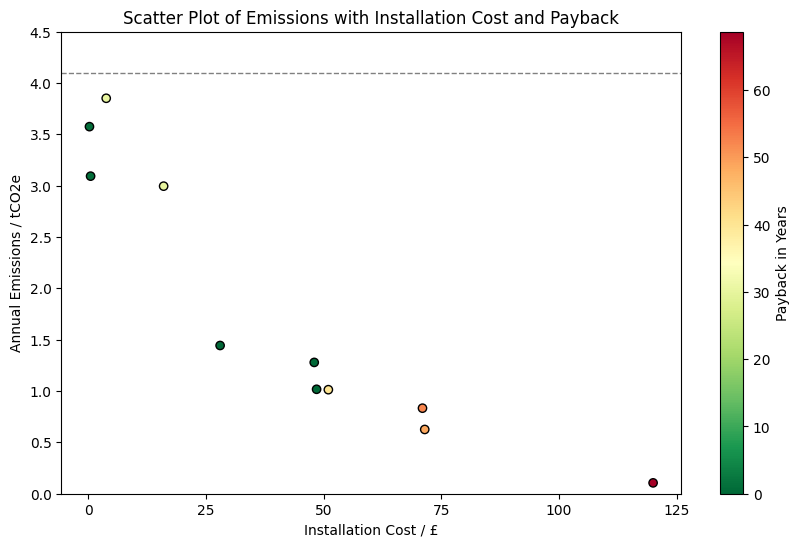

In [654]:

x = df['cost']
y = df['emissions']
z = df['payback']

xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['cost'], df['emissions'], c=df['payback'], cmap='RdYlGn_r', edgecolor='k')
plt.colorbar(scatter, label='Payback in Years')

# Modify x-axis labels to show in k£
plt.xticks(ticks=np.arange(0, 130000, 25000), labels=[f'{int(x/1000)}' for x in np.arange(0, 130000, 25000)])

plt.ylim([0,4.5])
plt.axhline(xmin=0, xmax=125000, y=4.1, color="gray", linestyle='--', linewidth=1, zorder=0)
plt.xlabel('Installation Cost / £')
plt.ylabel('Annual Emissions / tCO2e')
plt.title('Scatter Plot of Emissions with Installation Cost and Payback')
plt.show()


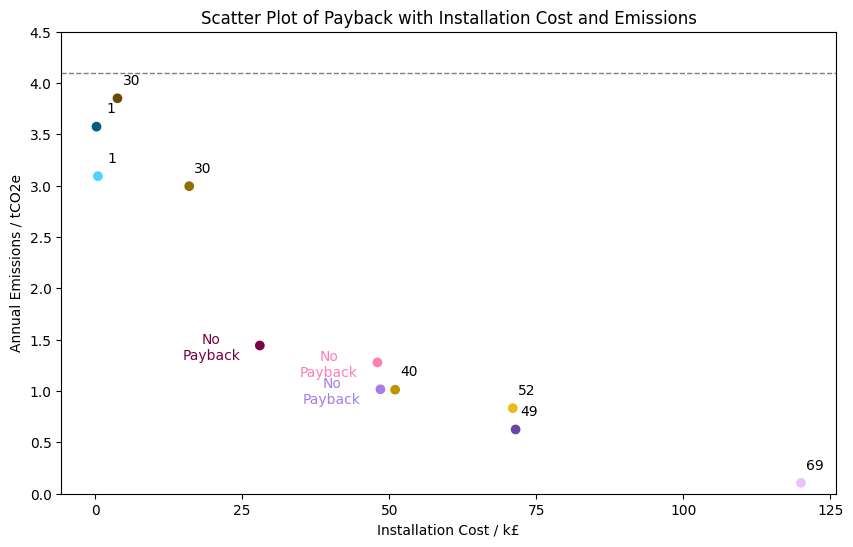

In [655]:

x = df['cost']
y = df['emissions']
z = df['payback']

xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['cost'], df['emissions'], color=intermediate_colors[1:])

# Modify x-axis labels to show in k£
plt.xticks(ticks=np.arange(0, 130000, 25000), labels=[f'{int(x/1000)}' for x in np.arange(0, 130000, 25000)])

# Annotating each point with the payback year
count=1
for i, row in df.iterrows():
    if row["savings"] > 0:
        plt.annotate(f"{row['payback']:.0f}", (row['cost'], row['emissions']), textcoords="offset points", xytext=(10, 10), ha='center', color='black')
    else:
        plt.annotate(f"No\nPayback", (row['cost'], row['emissions']), textcoords="offset points", xytext=(-35, -10), ha='center', color=intermediate_colors[count])
    count = count + 1

plt.ylim([0,4.5])
plt.axhline(xmin=0, xmax=125000, y=4.1, color="gray", linestyle='--', linewidth=1, zorder=0)
plt.xlabel('Installation Cost / k£')
plt.ylabel('Annual Emissions / tCO2e')
plt.title('Scatter Plot of Payback with Installation Cost and Emissions')
plt.show()


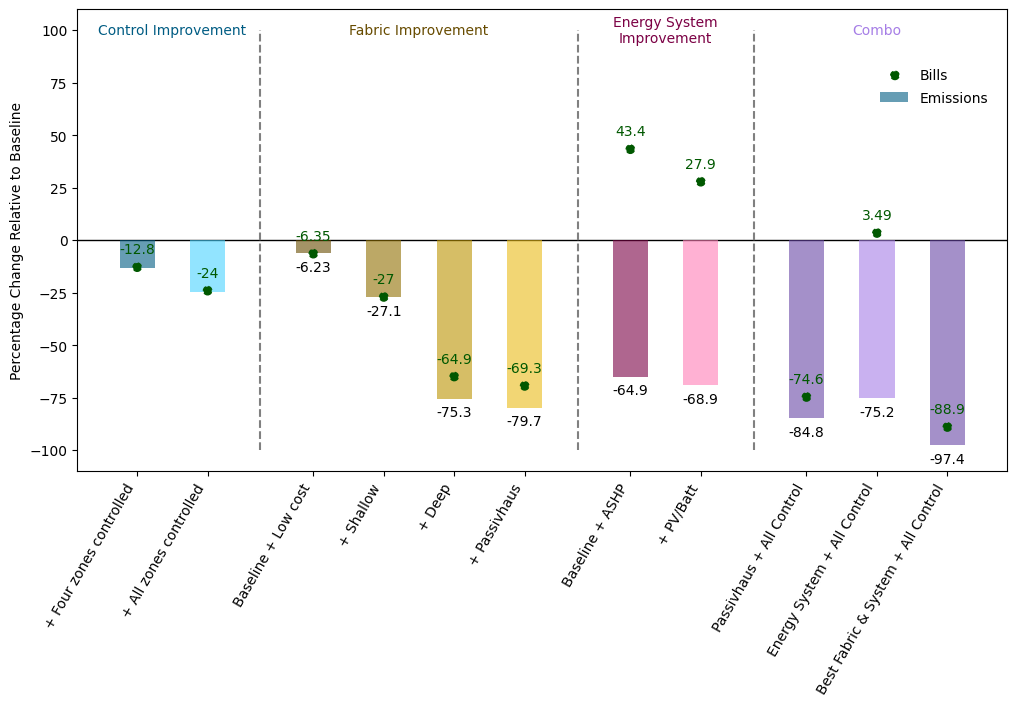

In [542]:
# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

baselines = out_data["relative_emissions"].iloc[:1]
control = out_data["relative_emissions"].iloc[1:3]
fabric = out_data["relative_emissions"].iloc[3:7]
system = out_data["relative_emissions"].iloc[7:9]
best = out_data["relative_emissions"].iloc[9:]

savings_baselines = out_data["relative_savings"].iloc[:1]
savings_control = out_data["relative_savings"].iloc[1:3]
savings_fabric = out_data["relative_savings"].iloc[3:7]
savings_system = out_data["relative_savings"].iloc[7:9]
savings_best = out_data["relative_savings"].iloc[9:]

# Plot bars
#base = ax1.bar(np.arange(1), savings_baselines, color=intermediate_colors[0], width=0.5, alpha=0.6, label='Baseline')
cont = ax1.bar(np.arange(0,2)+0.5, control, color=intermediate_colors[1:3], width=0.5, alpha=0.6, label='Emissions')
fab = ax1.bar(np.arange(2,6)+1, fabric, color=intermediate_colors[3:7], width=0.5, alpha=0.6)
sys = ax1.bar(np.arange(6,8)+1.5, system, color=intermediate_colors[7:9], width=0.5, alpha=0.6)
bes = ax1.bar(np.arange(8,11)+2, best, color=intermediate_colors[9:11], width=0.5, alpha=0.6)

# Add data labels
for bar in fab:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height - 10, f'{height:.3g}', color='black', ha='center', va='bottom')

for bar in sys:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height - 10, f'{height:.3g}', color='black', ha='center', va='bottom')

for bar in bes:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height - 10, f'{height:.3g}', color='black', ha='center', va='bottom')

# Secondary y-axis
ax2 = ax1.twinx()
#ax2.scatter(np.arange(1), baselines, color='#F0F0F0', marker='o', linestyle='--', label='Emissions')
ax2.scatter(np.arange(0,2)+0.5, savings_control, color='#005800', marker='o', linestyle='--')
ax2.scatter(np.arange(2,6)+1, savings_fabric, color='#005800', marker='o', linestyle='--')
ax2.scatter(np.arange(6,8)+1.5, savings_system, color='#005800', marker='o', linestyle='--')
ax2.scatter(np.arange(8,11)+2, savings_best, color='#005800', marker='o', linestyle='--', label='Bills')

# Add data labels for the scatter plot
def add_scatter_labels(ax, x_data, y_data):
    for (x, y) in zip(x_data, y_data):
        ax.text(x, y + 5, f'{y:.3g}', color="#005800", ha='center', va='bottom')

#add_scatter_labels(ax2, np.arange(1), baselines)
add_scatter_labels(ax2, np.arange(0,2) + 0.5, savings_control)
add_scatter_labels(ax2, np.arange(2, 6) + 1, savings_fabric)
add_scatter_labels(ax2, np.arange(6, 8) + 1.5, savings_system)
add_scatter_labels(ax2, np.arange(8, 11) + 2, savings_best)

# Add labels
plt.text(1, 100, 'Control Improvement', ha='center', va='center', color=intermediate_colors[1])
plt.text(4.5, 100, 'Fabric Improvement', ha='center', va='center', color=intermediate_colors[3])
plt.text(8, 100, 'Energy System\nImprovement', ha='center', va='center', color=intermediate_colors[7])
plt.text(11, 100, 'Combo', ha='center', va='center', color=intermediate_colors[10])
plt.xticks(np.concatenate([np.arange(0,2)+0.5, np.arange(2,6)+1, np.arange(6,8)+1.5, np.arange(8,11)+2]), custom_labels, rotation=60, ha='right')


# Add labels
ax1.set_xticks(np.concatenate([np.arange(0,2)+0.5, np.arange(2,6)+1, np.arange(6,8)+1.5, np.arange(8,11)+2]))
ax1.set_xticklabels(custom_labels, rotation=60, ha='right')
ax1.set_ylim([-110,110])
ax2.set_ylim([-110,110])

ax1.axhline(xmin=0, xmax=14, y=0, color="black", linestyle='-', linewidth=1, zorder=0)

# Add titles
ax1.set_ylabel('Percentage Change Relative to Baseline')
ax2.axis('off')

#ax1.vlines(x=0.75, ymin=0, ymax=100, color='gray', linestyle='--')
ax1.vlines(x=2.25, ymin=-100, ymax=100, color='gray', linestyle='--')
ax1.vlines(x=6.75, ymin=-100, ymax=100, color='gray', linestyle='--')
ax1.vlines(x=9.25, ymin=-100, ymax=100, color='gray', linestyle='--')

ax1.legend(loc='upper left', bbox_to_anchor=(0.85, 0.85), frameon=False)
ax2.legend(loc='upper right', bbox_to_anchor=(0.95, 0.9), frameon=False)
# Tightening and show
#fig.tight_layout()
#plt.savefig("reduction_potential.svg")
plt.show()

In [10]:
out_data

,emissions,bill,cost,savings,payback,savings10,relative_savings,relative_emissions,absolute_emissions,bang_for_buck,emissions_for_buck
Baseline,4.107830,1966.086106,0.0,-0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,NaN,NaN
Control - Four zones,3.575438,1714.776512,240.0,251.309594,0.954997,2513.095935,-12.782227,-12.960422,0.532392,1.047123,2.218300
Control - All zones,3.093210,1494.846905,480.0,471.239201,1.018591,4712.392005,-23.968391,-24.699657,1.014620,0.981748,2.113791
Fabric - Low cost,3.851788,1841.161726,3800.0,124.924380,30.418402,1249.243797,-6.353963,-6.233009,0.256041,0.032875,0.067379
Fabric - Shallow,2.995755,1436.072211,16000.0,530.013895,30.187888,5300.138951,-26.957817,-27.072070,1.112075,0.033126,0.069505
Fabric - Deep,1.013312,690.835502,51000.0,1275.250604,39.992139,12752.506041,-64.862398,-75.332172,3.094517,0.025005,0.060677
Fabric - Passivhaus,0.833155,603.239013,71000.0,1362.847093,52.096820,13628.470929,-69.317772,-79.717888,3.274675,0.019195,0.046122
System\nASHP,1.443799,2819.274134,28000.0,-853.188028,0.000000,-8531.880283,43.395252,-64.852505,2.664030,-0.030471,0.095144
System\nASHP + PV/Batt,1.279069,2514.911575,48000.0,-548.825469,0.000000,-5488.254694,27.914620,-68.862655,2.828761,-0.011434,0.058933
Combo\nPassivhaus + All Control,0.625931,499.462140,71480.0,1466.623966,48.737783,14666.239659,-74.596121,-84.762478,3.481898,0.020518,0.048712


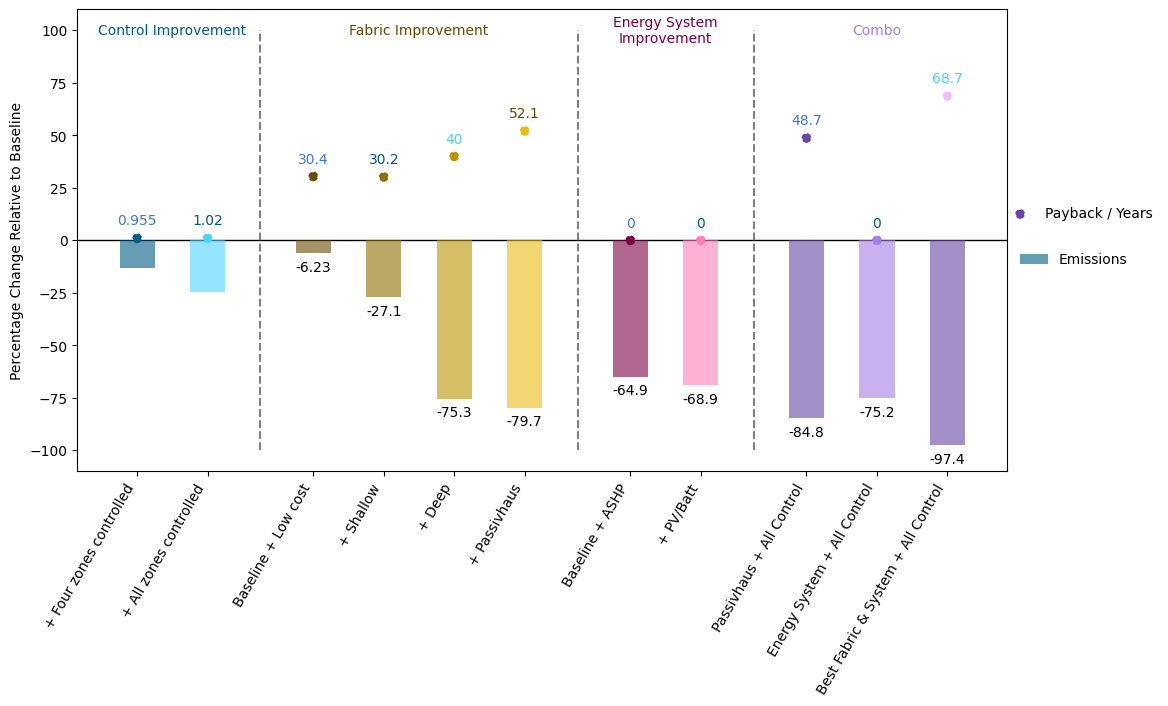

In [35]:
# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

baselines = out_data["relative_emissions"].iloc[:1]
control = out_data["relative_emissions"].iloc[1:3]
fabric = out_data["relative_emissions"].iloc[3:7]
system = out_data["relative_emissions"].iloc[7:9]
best = out_data["relative_emissions"].iloc[9:]

savings_baselines = out_data["payback"].iloc[:1]
savings_control = out_data["payback"].iloc[1:3]
savings_fabric = out_data["payback"].iloc[3:7]
savings_system = out_data["payback"].iloc[7:9]
savings_best = out_data["payback"].iloc[9:]

# Plot bars
#base = ax1.bar(np.arange(1), savings_baselines, color=intermediate_colors[0], width=0.5, alpha=0.6, label='Baseline')
cont = ax1.bar(np.arange(0,2)+0.5, control, color=intermediate_colors[1:3], width=0.5, alpha=0.6, label='Emissions')
fab = ax1.bar(np.arange(2,6)+1, fabric, color=intermediate_colors[3:7], width=0.5, alpha=0.6)
sys = ax1.bar(np.arange(6,8)+1.5, system, color=intermediate_colors[7:9], width=0.5, alpha=0.6)
bes = ax1.bar(np.arange(8,11)+2, best, color=intermediate_colors[9:11], width=0.5, alpha=0.6)

# Add data labels
for bar in fab:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height - 10, f'{height:.3g}', color='black', ha='center', va='bottom')

for bar in sys:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height - 10, f'{height:.3g}', color='black', ha='center', va='bottom')

for bar in bes:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height - 10, f'{height:.3g}', color='black', ha='center', va='bottom')

# Secondary y-axis
ax2 = ax1.twinx()
#ax2.scatter(np.arange(1), baselines, color='#F0F0F0', marker='o', linestyle='--', label='Emissions')
ax2.scatter(np.arange(0,2)+0.5, savings_control, color=intermediate_colors[1:3], marker='o', linestyle='--')
ax2.scatter(np.arange(2,6)+1, savings_fabric, color=intermediate_colors[3:7], marker='o', linestyle='--')
ax2.scatter(np.arange(6,8)+1.5, savings_system, color=intermediate_colors[7:9], marker='o', linestyle='--')
ax2.scatter(np.arange(8,11)+2, savings_best, color=intermediate_colors[9:12], marker='o', linestyle='--', label='Payback / Years')

# Add data labels for the scatter plot
def add_scatter_labels(ax, x_data, y_data):
    for i, (x, y) in enumerate(zip(x_data, y_data)):
        ax.text(x, y + 5, f'{y:.3g}', color=intermediate_colors[i], ha='center', va='bottom')

#add_scatter_labels(ax2, np.arange(1), baselines)
add_scatter_labels(ax2, np.arange(0,2) + 0.5, savings_control)
add_scatter_labels(ax2, np.arange(2, 6) + 1, savings_fabric)
add_scatter_labels(ax2, np.arange(6, 8) + 1.5, savings_system)
add_scatter_labels(ax2, np.arange(8, 11) + 2, savings_best)

# Add labels
plt.text(1, 100, 'Control Improvement', ha='center', va='center', color=intermediate_colors[1])
plt.text(4.5, 100, 'Fabric Improvement', ha='center', va='center', color=intermediate_colors[3])
plt.text(8, 100, 'Energy System\nImprovement', ha='center', va='center', color=intermediate_colors[7])
plt.text(11, 100, 'Combo', ha='center', va='center', color=intermediate_colors[10])
plt.xticks(np.concatenate([np.arange(0,2)+0.5, np.arange(2,6)+1, np.arange(6,8)+1.5, np.arange(8,11)+2]), custom_labels, rotation=60, ha='right')


# Add labels
ax1.set_xticks(np.concatenate([np.arange(0,2)+0.5, np.arange(2,6)+1, np.arange(6,8)+1.5, np.arange(8,11)+2]))
ax1.set_xticklabels(custom_labels, rotation=60, ha='right')
ax1.set_ylim([-110,110])
ax2.set_ylim([-110,110])

ax1.axhline(xmin=0, xmax=14, y=0, color="black", linestyle='-', linewidth=1, zorder=0)

# Add titles
ax1.set_ylabel('Percentage Change Relative to Baseline')
ax2.axis('off')

#ax1.vlines(x=0.75, ymin=0, ymax=100, color='gray', linestyle='--')
ax1.vlines(x=2.25, ymin=-100, ymax=100, color='gray', linestyle='--')
ax1.vlines(x=6.75, ymin=-100, ymax=100, color='gray', linestyle='--')
ax1.vlines(x=9.25, ymin=-100, ymax=100, color='gray', linestyle='--')

ax2.legend(loc='upper right', bbox_to_anchor=(1.17, 0.6), frameon=False)
ax1.legend(loc='upper left', bbox_to_anchor=(1, 0.5), frameon=False)
# Tightening and show
#fig.tight_layout()
#plt.savefig("reduction_potential.svg")
plt.show()

### Plotting installation cist vs bill savings after 10 years

In [590]:
bill_df

,emissions,bill,cost,savings,payback,savings10,relative_savings,relative_emissions,absolute_emissions,bang_for_buck,emissions_for_buck
Baseline,4.107830,1966.086106,0.0,-0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,NaN,NaN
Control - Four zones,3.575438,1714.776512,240.0,251.309594,0.954997,2513.095935,-12.782227,-12.960422,0.532392,1.047123,2.218300
Control - All zones,3.093210,1494.846905,480.0,471.239201,1.018591,4712.392005,-23.968391,-24.699657,1.014620,0.981748,2.113791
Fabric - Low cost,3.851788,1841.161726,3800.0,124.924380,30.418402,1249.243797,-6.353963,-6.233009,0.256041,0.032875,0.067379
Fabric - Shallow,2.995755,1436.072211,16000.0,530.013895,30.187888,5300.138951,-26.957817,-27.072070,1.112075,0.033126,0.069505
Fabric - Deep,1.013312,690.835502,51000.0,1275.250604,39.992139,12752.506041,-64.862398,-75.332172,3.094517,0.025005,0.060677
Fabric - Passivhaus,0.833155,603.239013,71000.0,1362.847093,52.096820,13628.470929,-69.317772,-79.717888,3.274675,0.019195,0.046122
System\nASHP,1.443799,2819.274134,28000.0,-853.188028,0.000000,-8531.880283,43.395252,-64.852505,2.664030,-0.030471,0.095144
System\nASHP + PV/Batt,1.279069,2514.911575,48000.0,-548.825469,0.000000,-5488.254694,27.914620,-68.862655,2.828761,-0.011434,0.058933
Combo\nPassivhaus + All Control,0.625931,499.462140,71480.0,1466.623966,48.737783,14666.239659,-74.596121,-84.762478,3.481898,0.020518,0.048712


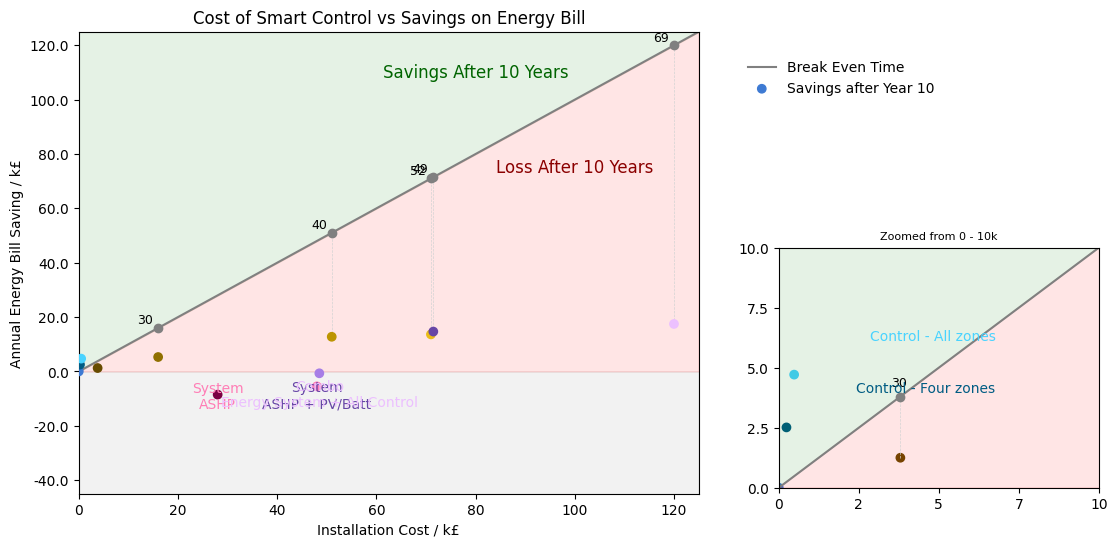

In [600]:
bill_df = out_data
# Create a plot with specific size
fig, ax = plt.subplots(figsize=(8, 6))

# Define the x values where you want to plot and shade (ensure full coverage of your data range)
x_values = np.linspace(0, 125000, 40000)

# Plot the line y = x with a label for the legend
ax.plot(x_values, x_values, color="gray", linestyle='-', zorder=2, label='Break Even Time')

# Shade above the line y = x in green
# Shade below the line y = x in red
ax.fill_between(x_values, x_values, 125000, color='green', alpha=0.1, zorder=1)
ax.fill_between(x_values, 0, x_values, color='red', alpha=0.1, zorder=1)

# Scatter plot
ax.scatter(bill_df['cost'], bill_df['savings10'], color=intermediate_colors, label='Savings after Year 10', zorder=3)

# Plot points on y = x and annotate with 'payback' at an offset
for idx, row in bill_df.iterrows():
    if not np.isnan(row['payback']) and row['payback']>0 and row['cost'] > 5000:  # Check if 'payback' is not NaN
        plt.scatter(row['cost'], row['cost'], color='gray', zorder=4)  # Point on y=x
        text_x = row['cost'] - 1000  # Shift text right by 10 units
        text_y = row['cost'] + 500  # Shift text down by 2 units
        plt.text(text_x, text_y, f"{row['payback']:.0f}", fontsize=9, color='black', ha='right', va='bottom')

# Plot vertical lines for x values greater than 15000
for i, x in enumerate(bill_df['cost']):
    if x > 20000:
        if bill_df["payback"].iloc[i] > 0:
            ax.vlines(x=x, ymin=bill_df["savings10"].iloc[i], ymax=x, color='lightgray', linestyle='--', linewidth=0.5)


# Set labels and title
ax.set_xlabel('Installation Cost / k£')
ax.set_ylabel('Annual Energy Bill Saving / k£')
ax.set_title('Cost of Smart Control vs Savings on Energy Bill')

# Enable grid
#ax.grid(True)

# Add text to the shaded areas
ax.text(80000, 110000, 'Savings After 10 Years', fontsize=12, color='darkgreen', ha='center', va='center')
ax.text(100000, 75000, 'Loss After 10 Years', fontsize=12, color='darkred', ha='center', va='center')

# Add angled title above the middle of the line y = x
#mid_point = max(x_values) / 2
#ax.text(mid_point + 70, mid_point + 70, 'Time to breakeven in years', fontsize=10, color='black', ha='center', va='bottom', rotation=38.5)

# Display the legend outside the plot on the right
ax.legend(loc='right', bbox_to_anchor=(1.4, 0.9), frameon=False)

# Modify x-axis labels to show in k£
plt.xticks(ticks=np.arange(-140000, 140000, 20000), labels=[f'{int(x/1000)}' for x in np.arange(-140000, 140000, 20000)])
plt.yticks(ticks=np.arange(-140000, 140000, 20000), labels=[f'{(x/1000)}' for x in np.arange(-140000, 140000, 20000)])

# Annotating each point with the payback year
count=1
for i, row in bill_df.iterrows():
    if row['savings'] < 0:
        plt.annotate(f"{i}", (row['cost'], row['savings']), textcoords="offset points", xytext=(0, -25), ha='center', color=intermediate_colors[count])
    count = count + 1

# Create a zoomed-in subplot outside the main plot with specified coordinates
ax_zoom = fig.add_axes([1., 0.12, 0.4, 0.4])  # [left, bottom, width, height]
ax_zoom.scatter(bill_df['cost'], bill_df['savings10'], color=intermediate_colors, label='Savings after Year 10')

# Annotate
text_x = 200
text_y = 250
for idx, row in bill_df.iterrows():
    if not np.isnan(row['payback']) and row['payback']>0 and 1000 < row['cost'] < 5000:  # Check if 'payback' is not NaN
        ax_zoom.scatter(row['cost'], row['cost'], color='gray', zorder=4)  # Point on y=x
        text_x = text_x + row['cost']   # Shift text right by 10 units
        text_y = text_y + row['cost'] + 50  # Shift text down by 2 units
        ax_zoom.text(text_x, text_y, f"{row['payback']:.0f}", fontsize=9, color='black', ha='right', va='bottom')

# Plot y=x
ax_zoom.plot(x_values, x_values, color="gray", linestyle='-', zorder=2, label='Break Even Time')

# Plot vertical lines for x values greater than 15000
for i, x in enumerate(bill_df['cost']):
    if bill_df["cost"].iloc[i] > 1000:
        ax_zoom.vlines(x=x, ymin=bill_df["savings10"].iloc[i], ymax=x, color='lightgray', linestyle='--', linewidth=0.5)


# Reusing the same colored shading
ax_zoom.fill_between(x_values, x_values, 20000, color='green', alpha=0.1, zorder=1)
ax_zoom.fill_between(x_values, 0, x_values, color='red', alpha=0.1, zorder=1)
ax_zoom.set_xlim(0, 10000)
ax_zoom.set_ylim(0, 10000)
ax_zoom.set_title('Zoomed from 0 - 10k', fontsize=8)

# Modify x-axis labels to show in k£
ax_zoom.set_xticks(ticks=np.arange(0, 12500, 2500), labels=[f'{int(x/1000)}' for x in np.arange(0, 12500, 2500)])
ax_zoom.set_yticks(ticks=np.arange(0, 12500, 2500), labels=[f'{(x/1000)}' for x in np.arange(0, 12500, 2500)])

# Annotating each point with the payback year
count=0
for i, row in bill_df.iterrows():
    if row['savings10'] > 2500:
        ax_zoom.annotate(f"{i}", (row['cost'], row['savings10']), textcoords="offset points", xytext=(100, 25), ha='center', color=intermediate_colors[count])
    count = count + 1

#ax_zoom.grid(True)

ax.fill_between(x_values, 0, -125000, color='gray', alpha=0.1, zorder=1)

# Set limits for x and y axes to ensure grid starts at 0
ax.set_xlim(0, 125000)  # x-axis limit set to the maximum of x_values to avoid extra space
ax.set_ylim(-45000, 125000)  # y-axis limit set slightly above the maximum bill value for clarity


# Indicate the zoomed-in area on the main plot
#mark_inset(ax, ax_zoom, loc1=3, loc2=2, fc="none", ec="0.5")

# Save Display the plot
plt.savefig("payback.svg")
plt.show()


### Energy bill and emissions reduction potential of different retrofit options

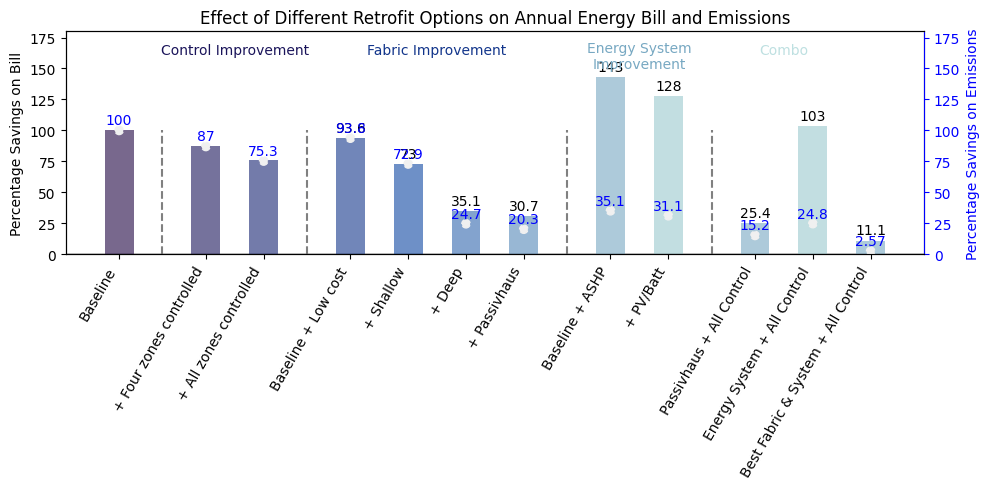

In [292]:
# Plotting
fig, ax1 = plt.subplots(figsize=(10, 5))

baselines = out_data["relative_emissions"].iloc[:1]
control = out_data["relative_emissions"].iloc[1:3]
fabric = out_data["relative_emissions"].iloc[3:7]
system = out_data["relative_emissions"].iloc[7:9]
best = out_data["relative_emissions"].iloc[9:]

savings_baselines = out_data["relative_savings"].iloc[:1]
savings_control = out_data["relative_savings"].iloc[1:3]
savings_fabric = out_data["relative_savings"].iloc[3:7]
savings_system = out_data["relative_savings"].iloc[7:9]
savings_best = out_data["relative_savings"].iloc[9:]

# Plot bars
base = ax1.bar(np.arange(1), savings_baselines, color=intermediate_colors[0], width=0.5, alpha=0.6, label='Baseline')
cont = ax1.bar(np.arange(1,3)+0.5, savings_control, color=intermediate_colors[1:3], width=0.5, alpha=0.6, label='Improving Control')
fab = ax1.bar(np.arange(3,7)+1, savings_fabric, color=intermediate_colors[3:7], width=0.5, alpha=0.6, label='Improving Fabric')
sys = ax1.bar(np.arange(7,9)+1.5, savings_system, color=intermediate_colors[7:9], width=0.5, alpha=0.6, label='Improving Energy System')
bes = ax1.bar(np.arange(9,12)+2, savings_best, color=intermediate_colors[7:9], width=0.5, alpha=0.6, label='Improving Control with Fabric/Energy')


# Add data labels
for bar in fab:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 2.5, f'{height:.3g}', ha='center', va='bottom')

for bar in sys:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 2.5, f'{height:.3g}', ha='center', va='bottom')

for bar in bes:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 2.5, f'{height:.3g}', ha='center', va='bottom')

# Secondary y-axis
ax2 = ax1.twinx()
ax2.scatter(np.arange(1), baselines, color='#F0F0F0', marker='o', linestyle='--', label='Emissions')
ax2.scatter(np.arange(1,3)+0.5, control, color='#F0F0F0', marker='o', linestyle='--', label='Emissions')
ax2.scatter(np.arange(3,7)+1, fabric, color='#F0F0F0', marker='o', linestyle='--', label='Emissions')
ax2.scatter(np.arange(7,9)+1.5, system, color='#F0F0F0', marker='o', linestyle='--', label='Emissions')
ax2.scatter(np.arange(9,12)+2, best, color='#F0F0F0', marker='o', linestyle='--', label='Emissions')

# Add data labels for the scatter plot
def add_scatter_labels(ax, x_data, y_data):
    for (x, y) in zip(x_data, y_data):
        ax.text(x, y + 2.5, f'{y:.3g}', color="blue", ha='center', va='bottom')

add_scatter_labels(ax2, np.arange(1), baselines)
add_scatter_labels(ax2, np.arange(1, 3) + 0.5, control)
add_scatter_labels(ax2, np.arange(3, 7) + 1, fabric)
add_scatter_labels(ax2, np.arange(7, 9) + 1.5, system)
add_scatter_labels(ax2, np.arange(9, 12) + 2, best)

# Add labels
plt.text(2, 165, 'Control Improvement', ha='center', va='center', color=intermediate_colors[1])
plt.text(5.5, 165, 'Fabric Improvement', ha='center', va='center', color=intermediate_colors[3])
plt.text(9, 160, 'Energy System\nImprovement', ha='center', va='center', color=intermediate_colors[7])
plt.text(11.5, 165, 'Combo', ha='center', va='center', color=intermediate_colors[10])
plt.xticks(np.concatenate([np.arange(1), np.arange(1,3)+0.5, np.arange(3,7)+1, np.arange(7,9)+1.5, np.arange(9,12)+2]), custom_labels, rotation=60, ha='right')


# Add labels
ax1.set_xticks(np.concatenate([np.arange(1), np.arange(1,3)+0.5, np.arange(3,7)+1, np.arange(7,9)+1.5, np.arange(9,12)+2]))
ax1.set_xticklabels(custom_labels, rotation=60, ha='right')
ax1.set_ylim([0,180])
ax2.set_ylim([0,180])

ax1.axhline(xmin=0, xmax=14, y=0, color="black", linestyle='-', linewidth=1, zorder=0)

# Add titles
ax1.set_ylabel('Percentage Savings on Bill')
ax2.set_ylabel('Percentage Savings on Emissions')
plt.title('Effect of Different Retrofit Options on Annual Energy Bill and Emissions')

# Set the color of the secondary y-axis
ax2.spines['right'].set_color('blue')
ax2.tick_params(axis='y', colors='blue')
ax2.yaxis.label.set_color('blue')

# Add a vertical lines

ax1.vlines(x=0.75, ymin=0, ymax=100, color='gray', linestyle='--')
ax1.vlines(x=3.25, ymin=0, ymax=100, color='gray', linestyle='--')
ax1.vlines(x=7.75, ymin=0, ymax=100, color='gray', linestyle='--')
ax1.vlines(x=10.25, ymin=0, ymax=100, color='gray', linestyle='--')

# Tightening and show
fig.tight_layout()
plt.savefig("reduction_potential.svg")
plt.show()

In [204]:
out_data["top"]=out_data["relative_emissions"].shift(1).fillna(100)
out_data.loc["no_control_case_0_rep", "top"] = 200
out_data.loc["no_control_case_1_rep", "top"] = 100
out_data.loc["no_control_case_5_rep", "top"] = 100
out_data.loc["all_zones_controlled_case_10_rep0", "top"] = 100

In [205]:
out_data

,emissions,bill,cost,savings,payback,savings10,relative_savings,relative_emissions,top
no_control_case_0_rep,4.107830,1966.086106,0.0,-0.000000,0.000000,-0.000000,100.000000,100.000000,200.000000
four_zones_controlled_case_0_rep,3.616449,1730.795463,240.0,235.290643,1.020015,2352.906430,88.032536,88.037955,100.000000
all_zones_controlled_case_0_rep,3.147098,1511.992184,480.0,454.093922,1.057050,4540.939217,76.903661,76.612193,88.037955
no_control_case_1_rep,4.163500,1978.952743,3800.0,-12.866637,0.000000,-128.666374,100.654429,101.355224,100.000000
no_control_case_2_rep,2.995755,1436.072211,16000.0,530.013895,30.187888,5300.138951,73.042183,72.927930,101.355224
no_control_case_3_rep,1.013312,690.835502,51000.0,1275.250604,39.992139,12752.506041,35.137602,24.667828,72.927930
no_control_case_4_rep,0.833155,603.239013,71000.0,1362.847093,52.096820,13628.470929,30.682228,20.282112,24.667828
no_control_case_5_rep,1.443799,2819.274134,28000.0,-853.188028,0.000000,-8531.880283,143.395252,35.147495,100.000000
no_control_case_10_rep0,1.279069,2514.911575,48000.0,-548.825469,0.000000,-5488.254694,127.914620,31.137345,35.147495
all_zones_controlled_case_10_rep0,1.023883,2056.425171,48500.0,-90.339065,0.000000,-903.390648,104.594868,24.925169,100.000000


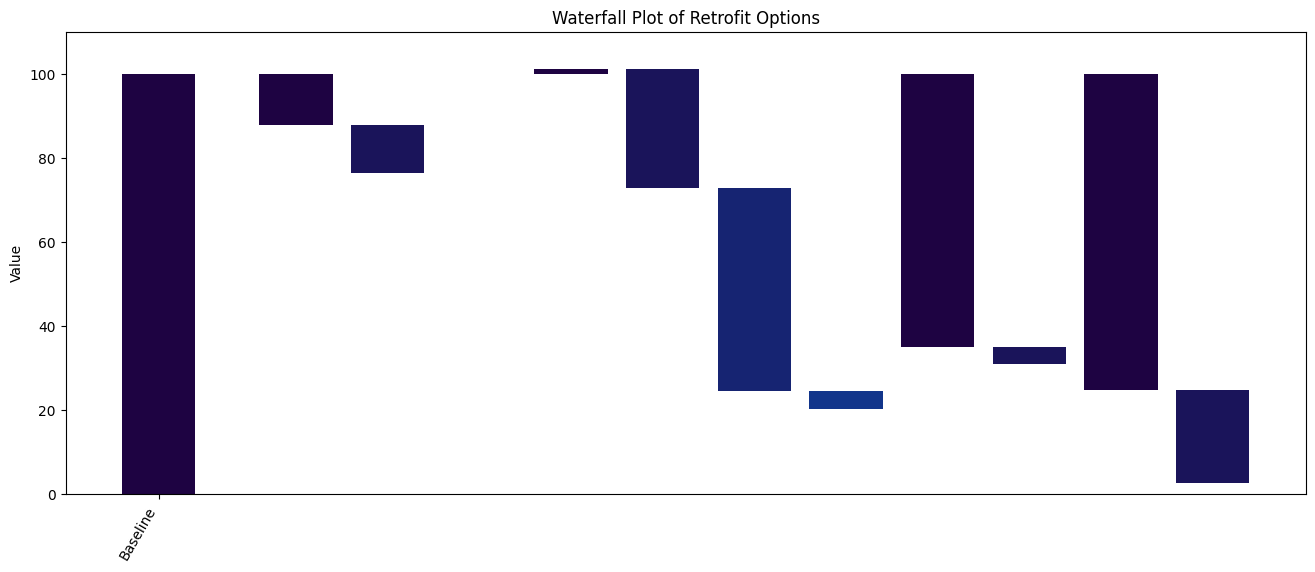

In [247]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(16, 6))


# Plot the waterfall
def plot_waterfall(top, values, offset):
        for i in range(len(top)):
                plt.bar(i+offset, top.iloc[i] - values.iloc[i], bottom=values.iloc[i], color=intermediate_colors[i]) # if out_data["top"].iloc[i] - out_data["relative_emissions"].iloc[i] >= 0 else 'r')




for i in range(1):
        plt.bar(custom_labels[i], out_data["top"].iloc[i] - out_data["relative_emissions"].iloc[i], bottom=(100-out_data["relative_emissions"].iloc[i]) if i ==0 else out_data["relative_emissions"].iloc[i], color=intermediate_colors[i]) # if out_data["top"].iloc[i] - out_data["relative_emissions"].iloc[i] >= 0 else 'r')

plot_waterfall(out_data["top"].iloc[1:3], out_data["relative_emissions"].iloc[1:3],1.5)
plot_waterfall(out_data["top"].iloc[3:7], out_data["relative_emissions"].iloc[3:7],4.5)
plot_waterfall(out_data["top"].iloc[7:9], out_data["relative_emissions"].iloc[7:9],8.5)
plot_waterfall(out_data["top"].iloc[9:], out_data["relative_emissions"].iloc[9:],10.5)


# Labels and titles
plt.xticks(rotation=60, ha='right')
ax.set_ylabel('Value')
plt.title('Waterfall Plot of Retrofit Options')
plt.ylim([0,110])

# Tight layout
#fig.tight_layout()
plt.show()


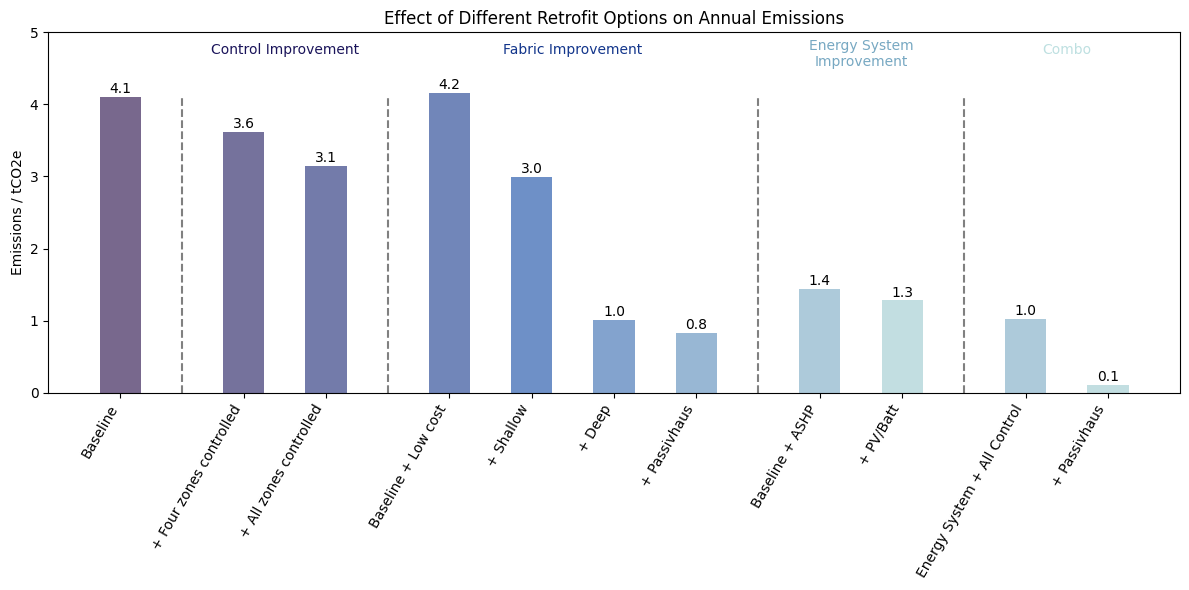

In [74]:
# Different labelling options
custom_labels = ['Baseline\nCase 0',
                 'Four zones controlled\nCase0',
                 'All zones controlled\nCase0',
                 'Low cost\nCase1',
                 'Shallow\nCase2',
                 'Deep\nCase3',
                 'Passivhaus\nCase4',
                 'Baseline + ASHP\nCase5',
                 'Baseline + ASHP + PV/Batt\nCase10',
                 'Baseline + ASHP + PV/Batt + All Control\nCase10',
                 'Passivhaus + ASHP + PV/Batt + All Control\nCase14']

custom_labels = ['Baseline',
                 '+ Four zones controlled',
                 '+ All zones controlled',
                 'Baseline + Low cost',
                 '+ Shallow',
                 '+ Deep',
                 '+ Passivhaus',
                 'Baseline + ASHP',
                 '+ PV/Batt',
                 'Energy System + All Control',
                 '+ Passivhaus']


# Number of shades to generate between each pair of provided colors
num_shades = 4

# Generate intermediate colors
intermediate_colors = []
for i in range(len(colors) - 1):
    start_color = mcolors.to_rgb(colors[i])
    end_color = mcolors.to_rgb(colors[i + 1])
    for j in range(num_shades):
        intermediate_color = [(start_color[k] + (end_color[k] - start_color[k]) * j / num_shades) for k in range(3)]
        intermediate_colors.append(mcolors.to_hex(intermediate_color))

intermediate_colors = intermediate_colors[:11]

baselines = out_data["emissions"].iloc[:1]
control = out_data["emissions"].iloc[1:3]
fabric = out_data["emissions"].iloc[3:7]
system = out_data["emissions"].iloc[7:9]
best = out_data["emissions"].iloc[9:]

# Plotting
plt.figure(figsize=(12, 6))

# Plot bars
base = plt.bar(np.arange(1), baselines, color=intermediate_colors[0], width=0.5, alpha=0.6, label='Baseline')
cont = plt.bar(np.arange(1,3)+0.5, control, color=intermediate_colors[1:3], width=0.5, alpha=0.6, label='Improving Control')
fab = plt.bar(np.arange(3,7)+1, fabric, color=intermediate_colors[3:7], width=0.5, alpha=0.6, label='Improving Fabric')
sys = plt.bar(np.arange(7,9)+1.5, system, color=intermediate_colors[7:9], width=0.5, alpha=0.6, label='Improving Energy System')
bes = plt.bar(np.arange(9,11)+2, best, color=intermediate_colors[7:9], width=0.5, alpha=0.6, label='Improving Control with Fabric/Energy')

# Add data labels
for bar in base:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.1f}', ha='center', va='bottom')

for bar in cont:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.1f}', ha='center', va='bottom')

for bar in fab:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.1f}', ha='center', va='bottom')

for bar in sys:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.1f}', ha='center', va='bottom')

for bar in bes:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.1f}', ha='center', va='bottom')

# Add labels
plt.text(2, 4.75, 'Control Improvement', ha='center', va='center', color=intermediate_colors[1])
plt.text(5.5, 4.75, 'Fabric Improvement', ha='center', va='center', color=intermediate_colors[3])
plt.text(9, 4.7, 'Energy System\nImprovement', ha='center', va='center', color=intermediate_colors[7])
plt.text(11.5, 4.75, 'Combo', ha='center', va='center', color=intermediate_colors[10])
plt.xticks(np.concatenate([np.arange(1), np.arange(1,3)+0.5, np.arange(3,7)+1, np.arange(7,9)+1.5, np.arange(9,11)+2]), custom_labels, rotation=60, ha='right')
plt.ylim([0,5])

# Add titles
plt.ylabel('Emissions / tCO2e')
plt.title('Effect of Different Retrofit Options on Annual Emissions')

# Add a vertical lines
plt.vlines(x=0.75, ymin=0, ymax=4.1, color='gray', linestyle='--')
plt.vlines(x=3.25, ymin=0, ymax=4.1, color='gray', linestyle='--')
plt.vlines(x=7.75, ymin=0, ymax=4.1,  color='gray', linestyle='--')
plt.vlines(x=10.25, ymin=0, ymax=4.1,  color='gray', linestyle='--')

# Tightening and show
plt.tight_layout()
plt.show()


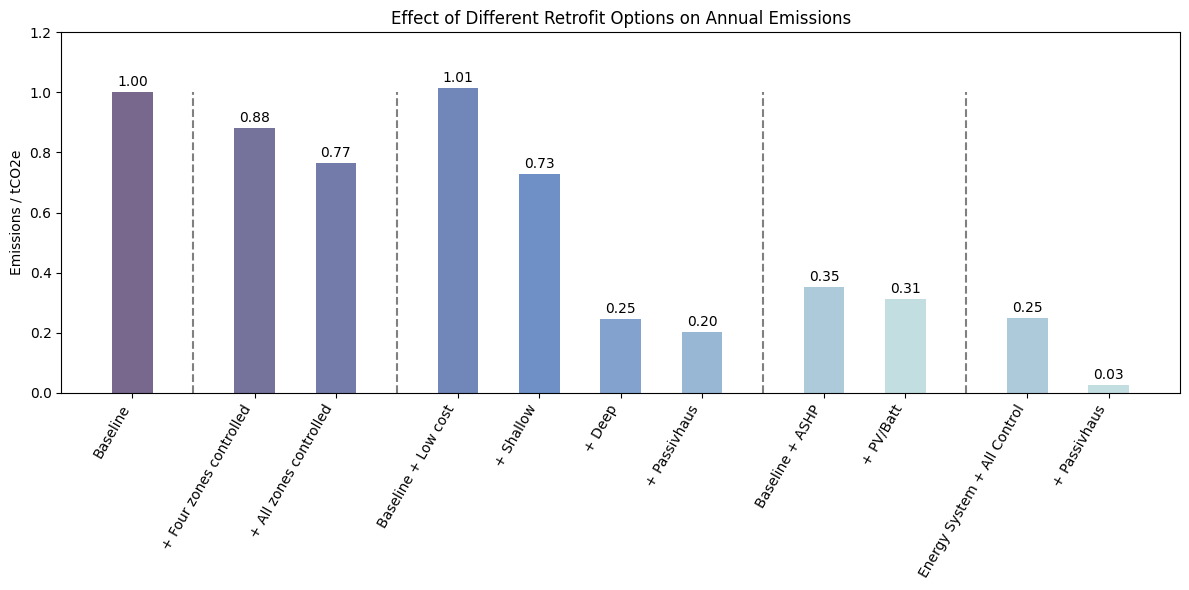

In [59]:
# Different labelling options
custom_labels = ['Baseline\nCase 0',
                 'Four zones controlled\nCase0',
                 'All zones controlled\nCase0',
                 'Low cost\nCase1',
                 'Shallow\nCase2',
                 'Deep\nCase3',
                 'Passivhaus\nCase4',
                 'Baseline + ASHP\nCase5',
                 'Baseline + ASHP + PV/Batt\nCase10',
                 'Baseline + ASHP + PV/Batt + All Control\nCase10',
                 'Passivhaus + ASHP + PV/Batt + All Control\nCase14']

custom_labels = ['Baseline',
                 '+ Four zones controlled',
                 '+ All zones controlled',
                 'Baseline + Low cost',
                 '+ Shallow',
                 '+ Deep',
                 '+ Passivhaus',
                 'Baseline + ASHP',
                 '+ PV/Batt',
                 'Energy System + All Control',
                 '+ Passivhaus']


# Number of shades to generate between each pair of provided colors
num_shades = 4

# Generate intermediate colors
intermediate_colors = []
for i in range(len(colors) - 1):
    start_color = mcolors.to_rgb(colors[i])
    end_color = mcolors.to_rgb(colors[i + 1])
    for j in range(num_shades):
        intermediate_color = [(start_color[k] + (end_color[k] - start_color[k]) * j / num_shades) for k in range(3)]
        intermediate_colors.append(mcolors.to_hex(intermediate_color))

intermediate_colors = intermediate_colors[:11]

baselines = out_data["relative_emissions"].iloc[:1]
control = out_data["relative_emissions"].iloc[1:3]
fabric = out_data["relative_emissions"].iloc[3:7]
system = out_data["relative_emissions"].iloc[7:9]
best = out_data["relative_emissions"].iloc[9:]

# Plotting
plt.figure(figsize=(12, 6))

# Plot bars
base = plt.bar(np.arange(1), baselines, color=intermediate_colors[0], width=0.5, alpha=0.6, label='Baseline')
cont = plt.bar(np.arange(1,3)+0.5, control, color=intermediate_colors[1:3], width=0.5, alpha=0.6, label='Improving Control')
fab = plt.bar(np.arange(3,7)+1, fabric, color=intermediate_colors[3:7], width=0.5, alpha=0.6, label='Improving Fabric')
sys = plt.bar(np.arange(7,9)+1.5, system, color=intermediate_colors[7:9], width=0.5, alpha=0.6, label='Improving Energy System')
bes = plt.bar(np.arange(9,11)+2, best, color=intermediate_colors[7:9], width=0.5, alpha=0.6, label='Improving Control with Fabric/Energy')

# Add data labels
for bar in base:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.2f}', ha='center', va='bottom')

for bar in cont:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.2f}', ha='center', va='bottom')

for bar in fab:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.2f}', ha='center', va='bottom')

for bar in sys:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.2f}', ha='center', va='bottom')

for bar in bes:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.2f}', ha='center', va='bottom')

# Add labels
#plt.text(2, 4.75, 'Control Improvement', ha='center', va='center', color=intermediate_colors[1])
#plt.text(5.5, 4.75, 'Fabric Improvement', ha='center', va='center', color=intermediate_colors[3])
#plt.text(9, 4.7, 'Energy System\nImprovement', ha='center', va='center', color=intermediate_colors[7])
#plt.text(11.5, 4.75, 'Combo', ha='center', va='center', color=intermediate_colors[10])
plt.xticks(np.concatenate([np.arange(1), np.arange(1,3)+0.5, np.arange(3,7)+1, np.arange(7,9)+1.5, np.arange(9,11)+2]), custom_labels, rotation=60, ha='right')
plt.ylim([0,1.2])

# Add titles
plt.ylabel('Emissions / tCO2e')
plt.title('Effect of Different Retrofit Options on Annual Emissions')

# Add a vertical lines
plt.vlines(x=0.75, ymin=0, ymax=1, color='gray', linestyle='--')
plt.vlines(x=3.25, ymin=0, ymax=1, color='gray', linestyle='--')
plt.vlines(x=7.75, ymin=0, ymax=1, color='gray', linestyle='--')
plt.vlines(x=10.25, ymin=0, ymax=1, color='gray', linestyle='--')

# Tightening and show
plt.tight_layout()
plt.show()


In [7]:
# Define the provided colors
colors = ['#1E0342', '#0E46A3', '#9AC8CD', '#E1F7F5']
# Custom labels for the x-axis
custom_labels = ['Manual Control', 'Constant Temp (20)', 'One Zone Controlled', 'Two Zones Controlled', 'Four Zones Controlled', 'Six Zones Controlled', 'All Zones Controlled']


# Number of shades to generate between each pair of provided colors
num_shades = 4

# Generate intermediate colors
intermediate_colors = []
for i in range(len(colors) - 1):
    start_color = mcolors.to_rgb(colors[i])
    end_color = mcolors.to_rgb(colors[i + 1])
    for j in range(num_shades):
        intermediate_color = [(start_color[k] + (end_color[k] - start_color[k]) * j / num_shades) for k in range(3)]
        intermediate_colors.append(mcolors.to_hex(intermediate_color))

intermediate_colors = intermediate_colors[:11]

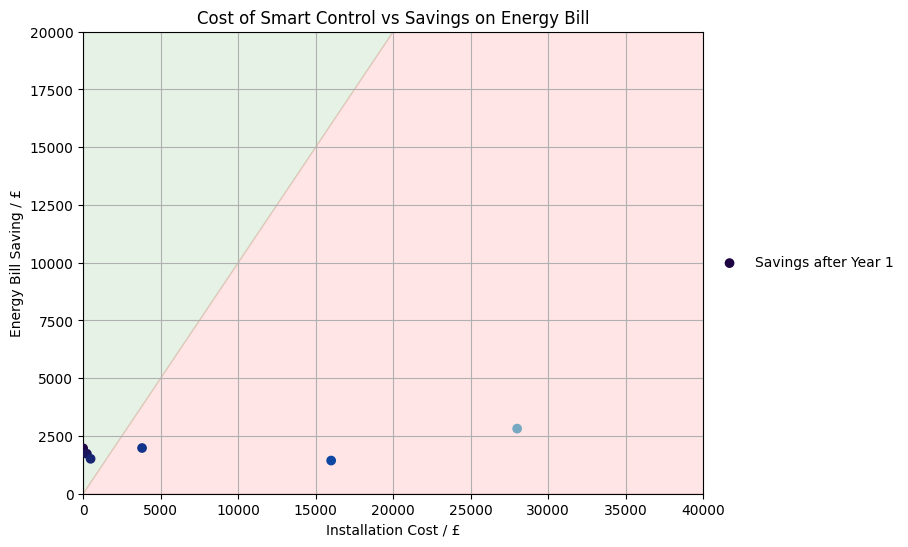

In [14]:
# Create a plot with specific size
plt.figure(figsize=(8, 6))

# Define the x values where you want to plot and shade (ensure full coverage of your data range)
x_values = np.linspace(0, 120000, 40000)  # Using linspace to generate a smooth line

# Plot the line y = x with a label for the legend
#plt.plot(x_values, x_values, color="gray", linestyle='-', zorder=2, label='Break Even Time')

# Shade above the line y = x in green
#plt.fill_between(x_values, x_values, 120000, color='green', alpha=0.1, zorder=1)

# Shade below the line y = x in red
#plt.fill_between(x_values, 0, x_values, color='red', alpha=0.1, zorder=1)

# Scatter plot
plt.scatter(bill_df['cost'], bill_df['bill'], color=intermediate_colors, label='Savings after Year 1', zorder=3)

# Plot points on y = x and annotate with 'payback' at an offset
#count = 0
#for idx, row in bill_df.iterrows():
#    if not np.isnan(row['payback']):  # Check if 'payback' is not NaN
#        plt.scatter(row['cost'], row['cost'], color='black', zorder=4)  # Point on y=x
#        text_x = row['cost'] - 10000# (10000 if count % 2 == 0 else -10000)  # Shift text left by 1000 units
#        text_y = row['cost'] + (10000 if count % 2 == 0 else -10000)  # Shift text up or down based on index
#        plt.text(text_x, text_y, f"{row['payback']:.2f}", fontsize=9, color='black', ha='right', va='bottom')
#        count=count+1

# Set labels and title
plt.xlabel('Installation Cost / £')
plt.ylabel('Energy Bill Saving / £')
plt.title('Cost of Smart Control vs Savings on Energy Bill')

# Set limits for x and y axes to ensure grid starts at 0
plt.xlim(0, 40000)  # x-axis limit set to the maximum of x_values to avoid extra space
plt.ylim(0, 20000)  # y-axis limit set slightly above the maximum bill value for clarity

# Enable grid
plt.grid(True)

# Add text to the shaded areas
#plt.text(20000, 102000, 'Savings After First Year', fontsize=12, color='darkgreen', ha='center', va='center')
#plt.text(100000, 22000, 'Loss After First Year', fontsize=12, color='darkred', ha='center', va='center')

# Add angled title above the middle of the line y = x
#mid_point = max(x_values) / 2
#plt.text(mid_point + 70, mid_point + 70, 'Time to breakeven in years', fontsize=10, color='black', ha='center', va='bottom', rotation=38.5)

# Display the legend outside the plot on the right
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

# Display the plot
plt.show()

KeyError: 'cost'

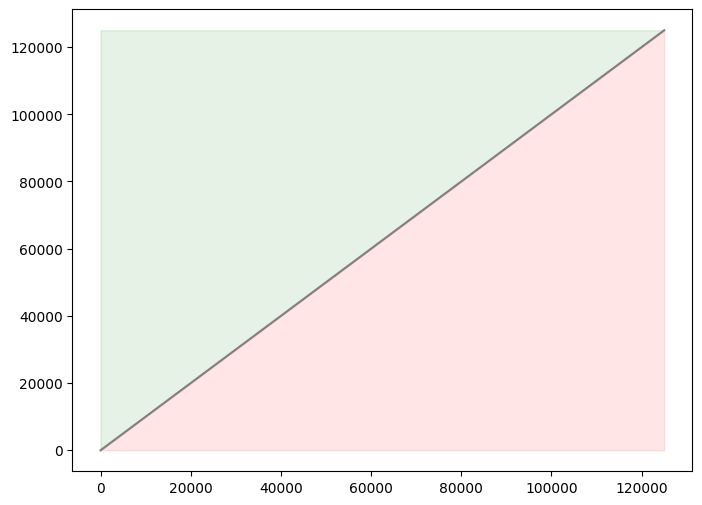

In [80]:

# Create a plot with specific size
fig, ax = plt.subplots(figsize=(8, 6))

# Define the x values where you want to plot and shade (ensure full coverage of your data range)
x_values = np.linspace(0, 125000, 40000)  # Using linspace to generate a smooth line

# Plot the line y = x with a label for the legend
ax.plot(x_values, x_values, color="gray", linestyle='-', zorder=2, label='Break Even Time')

# Shade above the line y = x in green
ax.fill_between(x_values, x_values, 125000, color='green', alpha=0.1, zorder=1)

# Shade below the line y = x in red
ax.fill_between(x_values, 0, x_values, color='red', alpha=0.1, zorder=1)

# Scatter plot
ax.scatter(bill_df['cost'], bill_df['savings'], color=intermediate_colors, label='Savings after Year 1', zorder=3)

# Set labels and title
ax.set_xlabel('Installation Cost / £')
ax.set_ylabel('Energy Bill Saving / £')
ax.set_title('Cost of Smart Control vs Savings on Energy Bill')

# Set limits for x and y axes to ensure grid starts at 0
ax.set_xlim(0, 125000)  # x-axis limit set to the maximum of x_values to avoid extra space
ax.set_ylim(0, 125000)  # y-axis limit set slightly above the maximum bill value for clarity

# Enable grid
ax.grid(True)

# Add text to the shaded areas
ax.text(80000, 110000, 'Savings After First Year', fontsize=12, color='darkgreen', ha='center', va='center')
ax.text(100000, 22000, 'Loss After First Year', fontsize=12, color='darkred', ha='center', va='center')

# Add angled title above the middle of the line y = x
mid_point = max(x_values) / 2
ax.text(mid_point + 70, mid_point + 70, 'Time to breakeven in years', fontsize=10, color='black', ha='center', va='bottom', rotation=38.5)

# Display the legend outside the plot on the right
ax.legend(loc='right', bbox_to_anchor=(1.4, 0.9), frameon=False)

# Create a zoomed-in subplot outside the main plot with specified coordinates
ax_zoom = fig.add_axes([1., 0.3, 0.4, 0.4])  # [left, bottom, width, height]
ax_zoom.scatter(bill_df['cost'], bill_df['savings'], color=intermediate_colors, label='Savings after Year 1')
#ax_zoom.plot(x_values, x_values, color="gray", linestyle='-', zorder=2, label='Break Even Time')
# Reusing the same colored shading
#ax_zoom.fill_between(x_values, x_values, 750, color='green', alpha=0.1, zorder=1)
ax_zoom.fill_between(x_values, 0, x_values, color='red', alpha=0.1, zorder=1)
ax_zoom.set_xlim(0, 120000)
ax_zoom.set_ylim(0, 2000)
ax_zoom.grid(True)

# Indicate the zoomed-in area on the main plot
mark_inset(ax, ax_zoom, loc1=3, loc2=2, fc="none", ec="0.5")

# Display the plot
plt.show()


In [157]:
bill_df

,emissions,bill,savings,cost,payback
no_control_case_0_rep,4.107830,1966.086106,-0.000000,0.0,0.000000
four_zones_controlled_case_0_rep,3.616449,1730.795463,235.290643,240.0,1.020015
all_zones_controlled_case_0_rep,3.147098,1511.992184,454.093922,480.0,1.057050
no_control_case_1_rep,4.163500,1978.952743,-12.866637,3800.0,-295.337460
no_control_case_2_rep,2.995755,1436.072211,530.013895,16000.0,30.187888
no_control_case_3_rep,1.013312,690.835502,1275.250604,51000.0,39.992139
no_control_case_4_rep,0.833155,603.239013,1362.847093,71000.0,52.096820
no_control_case_5_rep,1.443799,2819.274134,-853.188028,28000.0,-32.818088
no_control_case_10_rep0,1.279069,2514.911575,-548.825469,48000.0,-87.459498
all_zones_controlled_case_10_rep0,1.023883,2056.425171,-90.339065,48500.0,-536.866306


In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

In [398]:
df = pd.read_csv("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/output/final_results_0.csv")
df = df.drop(columns=["episode_num"])
control_options = {
    "all_zones_controlled": ["eco", 0],
    "six_zones_controlled": ["eco", 6],
    "four_zones_controlled": ["eco", 4],
    "2_zones_controlled": ["eco", 2],
    "1_zone_controlled": ["eco", 1],
    "manual_control": ["manual", 0],
    "no_control": ["eco", 0],
}

# Create a dictionary to store statistics for each control option
control_stats = {}

# Iterate over each key in control_options
for key, value in control_options.items():
    # Filter columns containing the key
    control_cols = [col for col in df.columns if key in col]
    # Calculate statistics for the filtered columns
    control_stats[key] = {
        'mean': df[control_cols].values.mean(axis=1)[0],
        'min': df[control_cols].values.min(axis=1)[0],
        'max': df[control_cols].values.max(axis=1)[0]
    }

# Convert the dictionary to a DataFrame
control_stats_df = pd.DataFrame(control_stats)
# Sort the DataFrame based on the mean values (largest to smallest)
sorted_df = control_stats_df.sort_values(by='mean', axis=1, ascending=False)
# Add a new row to the DataFrame
sorted_df.loc['cost'] = [0, 0, 60, 120, 240, 360, 480]
sorted_df.loc["bill"] = (sorted_df.loc["mean"]*65.7)/(52*3.6)





In [399]:
sorted_df

,manual_control,no_control,1_zone_controlled,2_zones_controlled,four_zones_controlled,six_zones_controlled,all_zones_controlled
mean,4690.612217,4108.309693,3968.765346,3772.026073,3617.302786,3388.343309,3147.320076
min,4315.474453,4107.815521,3968.025227,3770.553668,3616.449193,3386.970947,3145.393844
max,4787.448110,4109.388502,3969.540555,3772.707024,3619.094184,3390.694164,3151.162162
cost,0.000000,0.000000,60.000000,120.000000,240.000000,360.000000,480.000000
bill,1646.224480,1441.858690,1392.883991,1323.836074,1269.534151,1189.178181,1104.588296


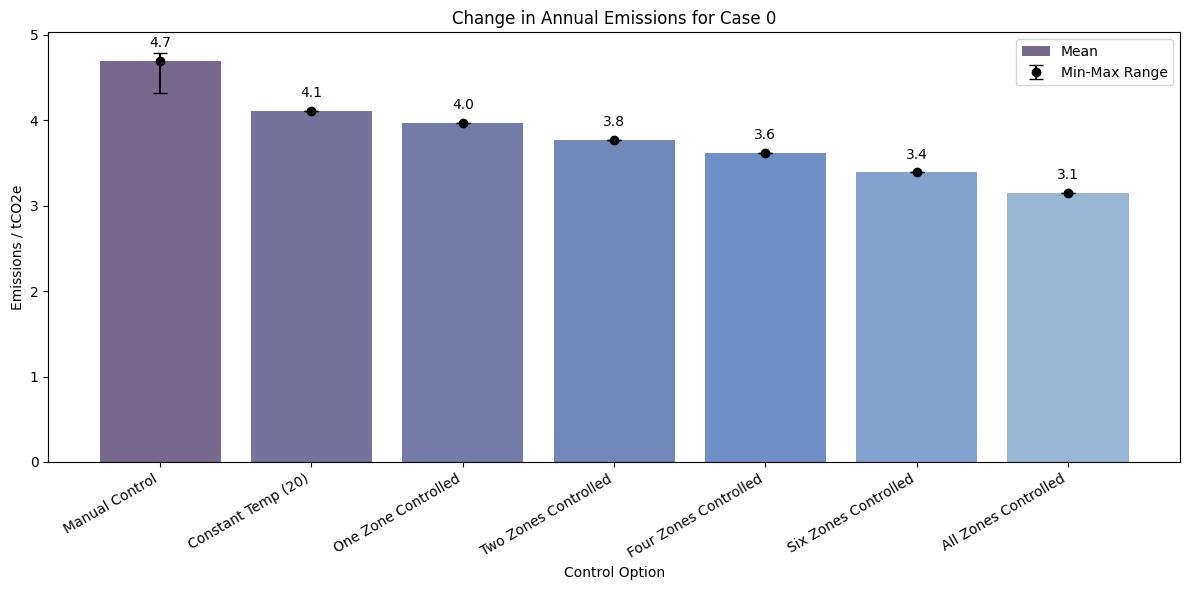

In [400]:

# Define the provided colors
colors = ['#1E0342', '#0E46A3', '#9AC8CD', '#E1F7F5']
# Custom labels for the x-axis
custom_labels = ['Manual Control', 'Constant Temp (20)', 'One Zone Controlled', 'Two Zones Controlled', 'Four Zones Controlled', 'Six Zones Controlled', 'All Zones Controlled']


# Number of shades to generate between each pair of provided colors
num_shades = 4

# Generate intermediate colors
intermediate_colors = []
for i in range(len(colors) - 1):
    start_color = mcolors.to_rgb(colors[i])
    end_color = mcolors.to_rgb(colors[i + 1])
    for j in range(num_shades):
        intermediate_color = [(start_color[k] + (end_color[k] - start_color[k]) * j / num_shades) for k in range(3)]
        intermediate_colors.append(mcolors.to_hex(intermediate_color))

intermediate_colors = intermediate_colors[:7]

# Plotting
plt.figure(figsize=(12, 6))

# Plot bars for mean
bars = plt.bar(sorted_df.columns, [val / 1000 for val in sorted_df.loc["mean"]], color=intermediate_colors, alpha=0.6, label='Mean')

# Plot error bars for min and max
for i, col in enumerate(sorted_df.columns):
    mean_val = sorted_df[col].loc["mean"] / 1000
    min_val = sorted_df[col].loc["min"] / 1000
    max_val = sorted_df[col].loc["max"] / 1000
    plt.errorbar(col, mean_val, yerr=[[mean_val - min_val], [max_val - mean_val]],
                 fmt='o', color='black', capsize=5, label='Min-Max Range' if i == 0 else None)

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.125, f'{height:.1f}', ha='center', va='bottom')

plt.xlabel('Control Option')
plt.ylabel('Emissions / tCO2e')
plt.title('Change in Annual Emissions for Case 0')
plt.xticks(sorted_df.columns, custom_labels, rotation=30, ha='right')  # Set custom labels for x-axis ticks
plt.legend()
plt.tight_layout()
plt.show()

In [401]:
cost_df = sorted_df.drop(columns=["manual_control"])

In [402]:
# Calculate the relative difference in mean for each column compared to 'manual_control'
relative_mean_diff = (cost_df.loc['mean'] - cost_df.loc['mean', 'no_control']) / cost_df.loc['mean', 'no_control']

rel_df = pd.DataFrame(relative_mean_diff)
rel_df = rel_df.T
rel_df.loc['cost'] = [0, 60, 120, 240, 360, 480]
rel_df = rel_df.T
mean_cost_df = rel_df

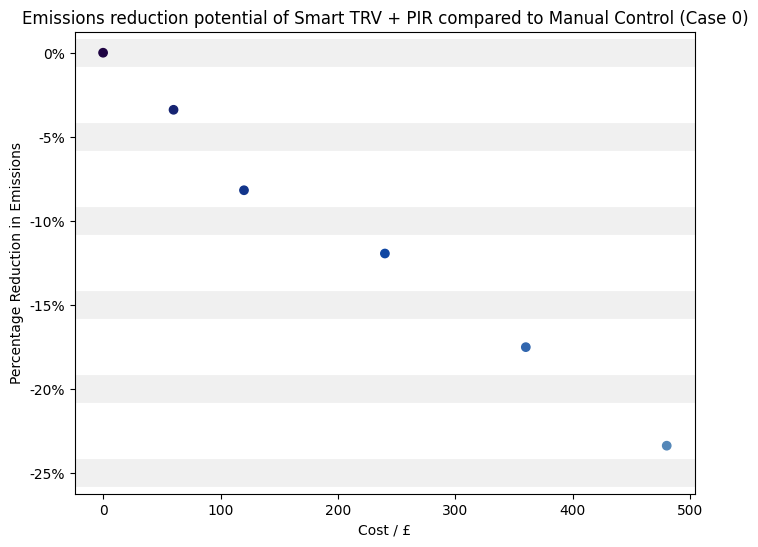

In [403]:

if len(intermediate_colors) > 6: # Remove the second color
    del intermediate_colors[1]

# Plot
plt.figure(figsize=(8, 6))

# Add horizontal lines for each 5% interval with thicker lines
for i in range(-25, 1, 5):
    plt.axhline(y=i / 100, color="#F0F0F0", linestyle='-', linewidth=20, zorder=0)

# Plot scatter points using the color palette
plt.scatter(rel_df['cost'], rel_df['mean'], color=intermediate_colors, label='Relative Mean Difference', zorder=1)

plt.xlabel('Cost / £')
plt.ylabel('Percentage Reduction in Emissions')

# Format y-axis ticks as percentages
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))

plt.title('Emissions reduction potential of Smart TRV + PIR compared to Manual Control (Case 0)')
plt.show()


In [404]:
# Calculate the relative difference in mean for each column compared to 'no_control'
relative_bill_diff = abs(cost_df.loc['bill'] - cost_df.loc['bill', 'no_control'])

bill_df = pd.DataFrame(relative_bill_diff)
bill_df = bill_df.T
bill_df.loc['cost'] = [0, 60, 120, 240, 360, 480]
bill_df = bill_df.T
bill_df["payback"] = ((bill_df["cost"] - bill_df["bill"])/ bill_df["bill"]) +1
bill_df.fillna(0)

,bill,cost,payback
no_control,0.000000,0.0,0.000000
1_zone_controlled,48.974699,60.0,1.225122
2_zones_controlled,118.022617,120.0,1.016754
four_zones_controlled,172.324539,240.0,1.392721
six_zones_controlled,252.680510,360.0,1.424724
all_zones_controlled,337.270394,480.0,1.423190


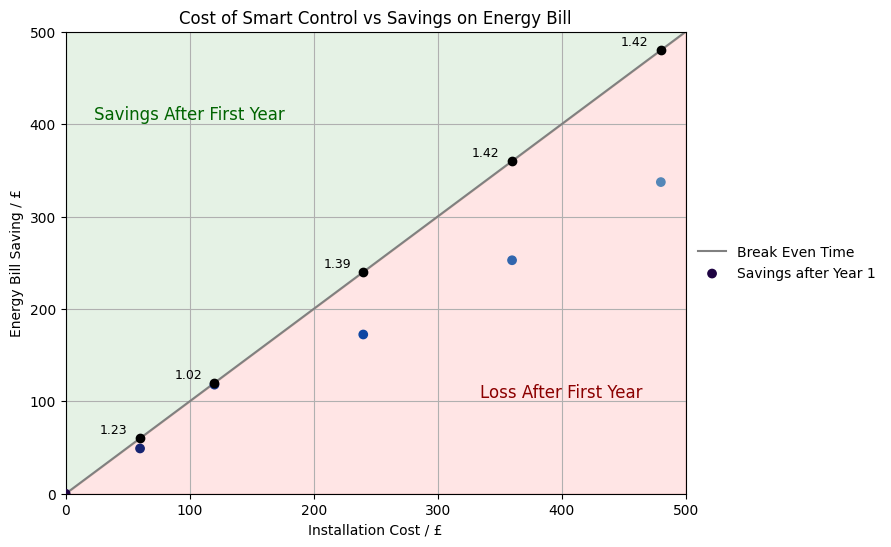

In [405]:
# Create a plot with specific size
plt.figure(figsize=(8, 6))

# Define the x values where you want to plot and shade (ensure full coverage of your data range)
x_values = np.linspace(0, 500, 500)  # Using linspace to generate a smooth line

# Plot the line y = x with a label for the legend
plt.plot(x_values, x_values, color="gray", linestyle='-', zorder=2, label='Break Even Time')

# Shade above the line y = x in green
plt.fill_between(x_values, x_values, 500, color='green', alpha=0.1, zorder=1)

# Shade below the line y = x in red
plt.fill_between(x_values, 0, x_values, color='red', alpha=0.1, zorder=1)

# Scatter plot
plt.scatter(bill_df['cost'], bill_df['bill'], color=intermediate_colors, label='Savings after Year 1', zorder=3)

# Plot points on y = x and annotate with 'payback' at an offset
for idx, row in bill_df.iterrows():
    if not np.isnan(row['payback']):  # Check if 'payback' is not NaN
        plt.scatter(row['cost'], row['cost'], color='black', zorder=4)  # Point on y=x
        text_x = row['cost'] - 10  # Shift text right by 10 units
        text_y = row['cost'] + 2  # Shift text down by 2 units
        plt.text(text_x, text_y, f"{row['payback']:.2f}", fontsize=9, color='black', ha='right', va='bottom')

# Set labels and title
plt.xlabel('Installation Cost / £')
plt.ylabel('Energy Bill Saving / £')
plt.title('Cost of Smart Control vs Savings on Energy Bill')

# Set limits for x and y axes to ensure grid starts at 0
plt.xlim(0, max(x_values))  # x-axis limit set to the maximum of x_values to avoid extra space
plt.ylim(0, 500)  # y-axis limit set slightly above the maximum bill value for clarity

# Enable grid
plt.grid(True)

# Add text to the shaded areas
plt.text(100, 410, 'Savings After First Year', fontsize=12, color='darkgreen', ha='center', va='center')
plt.text(400, 110, 'Loss After First Year', fontsize=12, color='darkred', ha='center', va='center')

# Add angled title above the middle of the line y = x
# mid_point = max(x_values) / 2
# plt.text(mid_point + 70, mid_point + 70, 'Time to breakeven in years', fontsize=10, color='black', ha='center', va='bottom', rotation=38.5)

# Display the legend outside the plot on the right
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

# Display the plot
plt.show()


In [294]:
bill_df["saving5yr"] = bill_df["bill"]*3 - bill_df["cost"]

In [295]:
bill_df

,bill,cost,saving5yr
0,0.000000,0.0,0.000000
1,48.974699,60.0,86.924097
2,118.022617,120.0,234.067851
3,172.324539,240.0,276.973617
4,252.680510,360.0,398.041530
5,337.270394,480.0,531.811182


In [4]:
# pylint: disable=all
import os
import pandas as pd
import numpy as np

control_options = {
    "all_zones_controlled": ["eco", 0],
    "six_zones_controlled": ["eco", 6],
    "four_zones_controlled": ["eco", 4],
    "2_zones_controlled": ["eco", 2],
    "1_zone_controlled": ["eco", 1],
    "manual_control": ["manual", 0],
    "no_control": ["eco", 0],
}
reps = np.arange(5)
cases = np.arange(5)

for case in cases:
    data = {}
    for rep in reps:
        for k, i in control_options.items():
            if "manual_control" in k:
                dir_name = (
                    f"Eplus-env-2024-05-09_{k}_zone_{i[-1]}_{i[0]}_2022_case_{case}_rep_{rep}-res1"
                )
            else:
                dir_name = (
                    f"Eplus-env-2024-05-07_{k}_zone_{i[-1]}_{i[0]}_2022_case_{case}_rep_{rep}-res1"
                )
            file_name = "/progress.csv"
            path = dir_name + file_name

            # Check if the directory exists
            if os.path.exists(dir_name):
                df = pd.read_csv(path, index_col=0)
                emissions = df["cumulative_emissions"]
                data[k] = emissions
            else:
                print(f"Directory '{dir_name}' does not exist. Skipping...")

        # Check if data is not empty before creating DataFrame and saving to CSV
        if data:
            out_data = pd.DataFrame(data)
            out_data.to_csv(f"final_results_{case}.csv")
        else:
            print(f"No data for case '{case}'. Skipping CSV creation.")
